# 기본환경 세팅

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#-----------------------------------------------------------------------------------  인코딩
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

#-----------------------------------------------------------------------------------  정규화
from sklearn.preprocessing import MinMaxScaler,  RobustScaler, StandardScaler
from sklearn.pipeline import Pipeline

#-----------------------------------------------------------------------------------  모델
from sklearn.linear_model import LogisticRegression          # 선형모델
from sklearn.tree import DecisionTreeClassifier              # 트리모델
from sklearn.ensemble import RandomForestClassifier          # 배깅모델   : 데이터N,  똑같은모델N(앙상블)
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMClassifier                          # 부스팅모델 : 데이터1,  다양한모델N(앙상블)
from xgboost import XGBClassifier
import xgboost as xgb


#-----------------------------------------------------------------------------------  평가
from sklearn.metrics import accuracy_score,      f1_score,  precision_score , recall_score,         roc_auc_score
from sklearn.metrics import                                 precision_recall_curve,                 roc_curve
from sklearn.metrics import classification_report,          confusion_matrix

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#-----------------------------------------------------------------------------------  교차검증
from sklearn.model_selection import train_test_split,                     KFold, StratifiedKFold
from sklearn.model_selection import cross_val_score, cross_validate,      GridSearchCV

import warnings
warnings.filterwarnings('ignore')

sns.set()

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Hancom Gothic'
plt.rcParams['axes.unicode_minus'] = False

#-------------------- 주피터 , 출력결과 넓이 늘리기 ---------------
# from IPython.core.display import display, HTML
from IPython.display import display, HTML
display(HTML("<style>.container{width:100% !important;}</style>"))
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('max_colwidth', None)

# 데이터 loading

In [2]:
df = pd.read_csv("Steel_industry_data.csv")

## 컬럼명 재정의

In [3]:
df.columns = ['date', 'Usage_kWh', 'Lagging_Current_Reactive_Power_kVarh',
               'Leading_Current_Reactive_Power_kVarh', 'CO2_ppm',
               'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
               'WeekStatus', 'Day_of_week', 'Load_Type']

print()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive_Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2_ppm                               35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  object 
 9   Day_of_week                           35040 non-null  object 
 10  Load_Type                             35040 non-null  object 
dtypes: float64(6),

### 컬럼 설명

<big><b> Attribute Information: </b></big>

<pre>
<b>Date</b>              Continuous-time data taken on the first of the month  
<b>Usage_kWh</b>         Industry Energy Consumption Continuous kWh  
<b>Lagging Current</b>   reactive power Continuous kVarh  
<b>Leading Current</b>   reactive power Continuous kVarh  
<b>CO2_ppm</b>           Continuous ppm  
<b>NSM</b>               Number of Seconds from midnight Continuous S  
<b>Week status</b>       Categorical (Weekend (0) or a Weekday(1))
<b>Day of week</b>       Categorical Sunday, Monday : Saturday  
<b>Load Type</b>         Categorical Light Load, Medium Load, Maximum Load
</pre>

# 전처리

## 시간 관련 변수 정리

In [4]:
# 1. 시간 기준 오름차순 정렬 (가장 중요한 선행 작업)
# 'timestamp' 부분은 실제 사용 중인 날짜/시간 컬럼명으로 변경해야 합니다.
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df = df.sort_values(by='date', ascending=True)

# 2. 기존의 꼬인 인덱스를 완전히 파기하고 순차적인 새 인덱스 부여
df = df.reset_index(drop=True)

In [5]:
# 1. 시간 기반 피처 (NSM 활용)
# 시간 관련 피처 추출 (한국 전력 요금 체계 대응용)
df['Hour'] = df['NSM'] // 3600
df['DayOfWeek'] = df['date'].dt.dayofweek # 0:월, 6:일
df['Month'] = df['date'].dt.month
df['Year'] = df['date'].dt.year
df['Is_Weekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

### [수정] 한전 기준 계절로 매핑
df['Season'] = df['Month'].map(
                                    lambda x: 'Spring_Fall' if x in [3,4,5, 9, 10]
                                    else 'Summer' if x in [6,7,8]
                                    else 'Winter'
                                )

### 월, 주 컬럼에 순환성 부여

In [6]:
###[수정] 주, 월에 순환성 부여하는 코드
cyclic_targets = {'Month': 12, 'DayOfWeek': 7}

for col, period in cyclic_targets.items():
    # 이제 target_df[col]은 확실히 숫자이므로 계산이 가능합니다.
    df[f'{col}_sin'] = np.sin(2 * np.pi * df[col].astype(float) / period)
    df[f'{col}_cos'] = np.cos(2 * np.pi * df[col].astype(float) / period)

print("성공적으로 변환되었습니다. 이제 숫자로 계산된 sin/cos 피처를 확인할 수 있습니다.")

성공적으로 변환되었습니다. 이제 숫자로 계산된 sin/cos 피처를 확인할 수 있습니다.


## 전력 관련 피쳐 생성

In [7]:
# 순무효전력 기반 물리적 역률
df['Apparent_Power'] = np.sqrt(df['Usage_kWh']**2 + (df['Lagging_Current_Reactive_Power_kVarh'] - df['Leading_Current_Reactive_Power_kVarh'])**2)
df['PF_Physical'] = np.where(df['Apparent_Power'] > 0, df['Usage_kWh'] / df['Apparent_Power'], 1.0)


# 전력 사용의 변동성에 대한 피쳐
df['Motor_Moving_Avg_1h_std'] = df['Usage_kWh'].rolling(window=4, min_periods=2).std().bfill() # 1시간(15분*4) 이동평균 표준편차


# 모터 가동 비중 (%) 계산
# 데이터셋 전체에서의 최대 지상 무효전력을 '모터 100% 가동' 상태로 가정
max_lagging = df['Lagging_Current_Reactive_Power_kVarh'].max()
df['Motor_Operating_Rate'] = (df['Lagging_Current_Reactive_Power_kVarh'] / max_lagging) * 100

# 커패시터 가동 비중 (%) 계산
# 최대 진상 무효전력을 '커패시터 100% 가동' 상태로 가정
max_leading = df['Leading_Current_Reactive_Power_kVarh'].max()
df['Capacitor_Operating_Rate'] = (df['Leading_Current_Reactive_Power_kVarh'] / max_leading) * 100

# 무효전력 총량 및 활성비
df['Q_total_abs'] = ( df['Lagging_Current_Reactive_Power_kVarh']
                      + df['Leading_Current_Reactive_Power_kVarh'] )

df['Motor_Ratio'] = ( df['Lagging_Current_Reactive_Power_kVarh'] / df['Q_total_abs'] )

df['Capacitor_Ratio'] = ( df['Leading_Current_Reactive_Power_kVarh'] / df['Q_total_abs'] )


# 콘덴서 과보상 의심 구간
df['Over_Correction_Flag'] = ( (df['Capacitor_Ratio'] > 0.6) & (df['PF_Physical'] > 0.98) )

print("파생 피처 생성 완료. 상위 5개 행 확인:")
print(df.head())

파생 피처 생성 완료. 상위 5개 행 확인:
                 date  Usage_kWh  Lagging_Current_Reactive_Power_kVarh  \
0 2018-01-01 00:00:00       3.42                                  3.46   
1 2018-01-01 00:15:00       3.17                                  2.95   
2 2018-01-01 00:30:00       4.00                                  4.46   
3 2018-01-01 00:45:00       3.24                                  3.28   
4 2018-01-01 01:00:00       3.31                                  3.56   

   Leading_Current_Reactive_Power_kVarh  CO2_ppm  \
0                                   0.0      0.0   
1                                   0.0      0.0   
2                                   0.0      0.0   
3                                   0.0      0.0   
4                                   0.0      0.0   

   Lagging_Current_Power_Factor  Leading_Current_Power_Factor   NSM  \
0                         70.30                         100.0     0   
1                         73.21                         100.0   900   
2   

## CO2 피쳐 EDA 및 예측

### CO2 피쳐 이상 확인

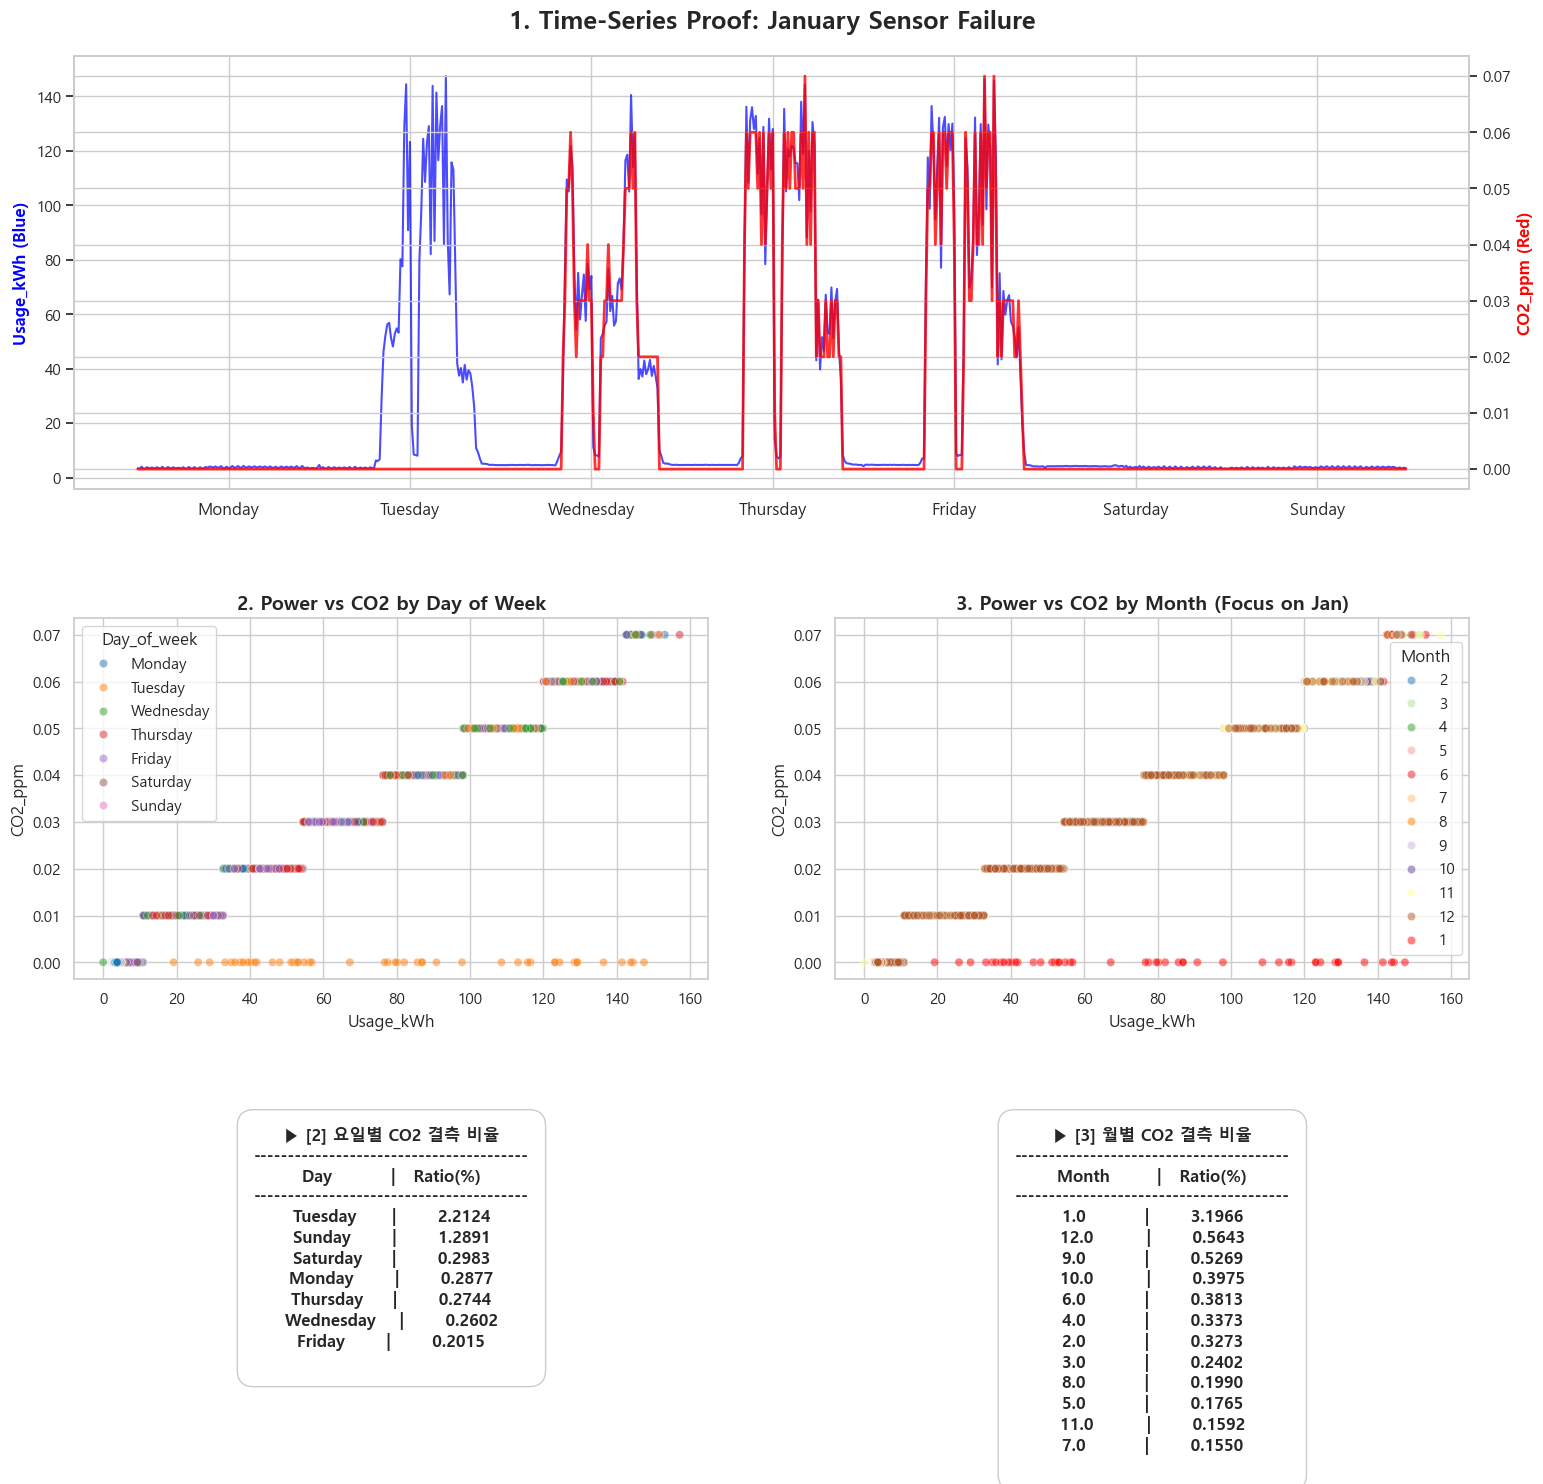

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
import matplotlib.font_manager as fm

# =====================================================================
# [설정] 한글 폰트 및 스타일 설정 (깨짐 방지)
# =====================================================================
# 시스템의 맑은 고딕이나 나눔고딕을 자동으로 찾습니다.
plt.rcParams['font.family'] = 'Malgun Gothic' # 윈도우용 
# plt.rcParams['font.family'] = 'AppleGothic' # 맥용 사용 시 주석 해제
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

sns.set_theme(style="whitegrid", font='Malgun Gothic') # Seaborn 테마에도 폰트 적용

day_labels = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# =====================================================================
# [1] 데이터 전처리
# =====================================================================
active_df = df[df['Usage_kWh'] > 10.0].copy()
jan_sample = df[df['Month'] == 1].sort_values('date').head(672)

# =====================================================================
# [2] 시각화 레이아웃 (3행 구조)
# =====================================================================
fig = plt.figure(figsize=(18, 16))
gs = gridspec.GridSpec(3, 2, height_ratios=[1.2, 1, 0.5])
plt.subplots_adjust(hspace=0.4, wspace=0.2)

# ---------------------------------------------------------------------
# [5번] 상단: 1월 시계열 증명 (X축 중앙 정렬)
# ---------------------------------------------------------------------
ax5 = fig.add_subplot(gs[0, :])
ax5_twin = ax5.twinx()

ax5.plot(range(len(jan_sample)), jan_sample['Usage_kWh'], color='blue', label='Usage_kWh', alpha=0.7)
ax5_twin.plot(range(len(jan_sample)), jan_sample['CO2_ppm'], color='red', label='CO2_ppm', alpha=0.8, linewidth=2)

step = 96
tick_pos = [i + (step/2) for i in range(0, len(jan_sample), step)]
x_labels = [val if isinstance(val, str) else day_labels[int(val)] for val in jan_sample['Day_of_week'].iloc[::step]]

ax5.set_xticks(tick_pos)
ax5.set_xticklabels(x_labels, rotation=0, ha='center', fontsize=12)
ax5.set_title('1. Time-Series Proof: January Sensor Failure', fontsize=18, fontweight='bold', pad=20)
ax5.set_ylabel('Usage_kWh (Blue)', color='blue', fontweight='bold')
ax5_twin.set_ylabel('CO2_ppm (Red)', color='red', fontweight='bold')

# ---------------------------------------------------------------------
# [1 & 2번] 중단: 산점도
# ---------------------------------------------------------------------
ax1 = fig.add_subplot(gs[1, 0])
sns.scatterplot(data=df, x='Usage_kWh', y='CO2_ppm', hue='Day_of_week', palette='tab10', alpha=0.5, ax=ax1)
ax1.set_title('2. Power vs CO2 by Day of Week', fontsize=14, fontweight='bold')

ax2 = fig.add_subplot(gs[1, 1])
custom_pal = {m: sns.color_palette("Paired", 12)[i] for i, m in enumerate(range(1, 13))}; custom_pal[1] = '#FF0000'
sns.scatterplot(data=df, x='Usage_kWh', y='CO2_ppm', hue='Month', palette=custom_pal, alpha=0.5, 
                hue_order=[m for m in range(2, 13)] + [1], ax=ax2)
ax2.set_title('3. Power vs CO2 by Month (Focus on Jan)', fontsize=14, fontweight='bold')

# ---------------------------------------------------------------------
# [3 & 4번] 하단: 통계 리포트 (텍스트 깨짐 방지 처리)
# ---------------------------------------------------------------------
def draw_report_box(ax, title, data, col_name):
    ax.axis('off')
    # 표 형태의 텍스트 생성 (justify='center'와 f-string 활용)
    report_text = f"▶ {title}\n" + "-"*40 + f"\n{col_name:<12} | {'Ratio(%)':>10}\n" + "-"*40 + "\n"
    for _, row in data.iterrows():
        name = str(row[0])
        val = f"{row[1]:>12.4f}"
        report_text += f"{name:<12} | {val}\n"
    
    # family='monospace'를 제거하거나 한글 지원 폰트와 병행 설정
    ax.text(0.5, 0.9, report_text, ha='center', va='top', fontsize=12, fontweight='bold',
            bbox=dict(facecolor='white', edgecolor='#CCCCCC', boxstyle='round,pad=1'))

# 3번 데이터 계산
zero_day = active_df.groupby('Day_of_week')['CO2_ppm'].apply(lambda x: (x == 0).sum() / len(x) * 100).reset_index()
if not isinstance(zero_day.iloc[0,0], str):
    zero_day.iloc[:,0] = zero_day.iloc[:,0].map({i: d for i, d in enumerate(day_labels)})
draw_report_box(fig.add_subplot(gs[2, 0]), "[2] 요일별 CO2 결측 비율", zero_day.sort_values(zero_day.columns[1], ascending=False), "Day")

# 4번 데이터 계산
zero_month = active_df.groupby('Month')['CO2_ppm'].apply(lambda x: (x == 0).sum() / len(x) * 100).reset_index()
draw_report_box(fig.add_subplot(gs[2, 1]), "[3] 월별 CO2 결측 비율", zero_month.sort_values(zero_month.columns[1], ascending=False), "Month")

plt.show();

### 이상 데이터에 대한 대치

#### 정밀 타겟팅: Usage는 있는데 CO2가 0인 이상치만 추출

In [9]:
# 1월 화요일 중, 전력은 사용하는데 CO2 센서만 0을 가리키는 지점을 찾습니다.
target_mask = (df['Month'] == 1) & \
              (df['Day_of_week'] == 'Tuesday') & \
              (df['Usage_kWh'] > 0) & \
              (df['CO2_ppm'] == 0)


In [10]:
missing_count = target_mask.sum()
print(f"🔍 분석 결과: 복구가 필요한 이상치 데이터는 총 {missing_count}개입니다.")

🔍 분석 결과: 복구가 필요한 이상치 데이터는 총 215개입니다.


#### 대치 전 전처리

In [11]:
# 복구 전 원본 데이터 보존 (시각화 비교용)
df_original = df.copy()

# 대상 데이터만 NaN으로 변경
df.loc[target_mask, 'CO2_ppm'] = np.nan

# 3. Feature Engineering (인코딩)
# 범주형 변수를 모델이 인식할 수 있게 변환
df_ml = pd.get_dummies(df, columns=['WeekStatus', 'Day_of_week', 'Load_Type'], drop_first=True)

# 학습에 사용할 특성 선택
features = ['Usage_kWh', 'NSM', 'Hour'] + [col for col in df_ml.columns if 'Load_Type_' in col]
target = 'CO2_ppm'


#### 모델링 및 예측

In [12]:
# 4. 모델링 및 예측
# 결측치가 없는 데이터로 학습
train_df = df_ml[df_ml[target].notnull()]
predict_df = df_ml[df_ml[target].isnull()]

X_train = train_df[features]
y_train = train_df[target]
X_predict = predict_df[features]

# RandomForest 모델 생성 및 학습
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
print("🚀 AI 모델 학습 및 복구 작업 중...")
rf_model.fit(X_train, y_train)

🚀 AI 모델 학습 및 복구 작업 중...


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


#### 결측치 대치 및 결과 시각화

<Axes: xlabel='Usage_kWh', ylabel='CO2_ppm'>

Text(0.5, 1.0, 'Before: Sensor Error (0 Values on Tuesday)')

<Axes: xlabel='Usage_kWh', ylabel='CO2_ppm'>

Text(0.5, 1.0, 'After: AI-Restored Data Pattern')

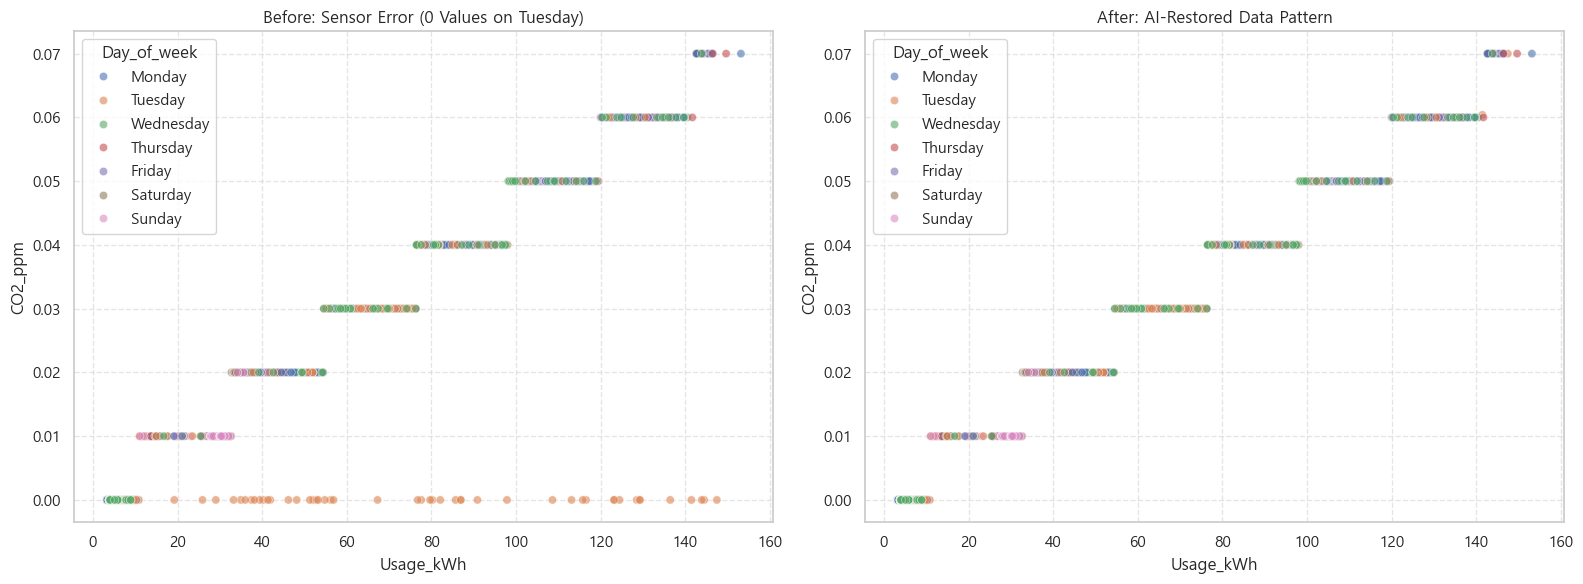

✅ 모든 복구 공정 및 시각화가 완료되었습니다.


In [13]:
# 결측치 채우기
predicted_values = rf_model.predict(X_predict)
df.loc[target_mask, 'CO2_ppm'] = predicted_values

# 5. 결과 시각화 (Before & After 비교)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 복구 전 산점도 (1월 데이터 중심)
jan_original = df_original[df_original['Month'] == 1]
sns.scatterplot(data=jan_original, x='Usage_kWh', y='CO2_ppm', hue='Day_of_week', ax=ax1, alpha=0.6)
ax1.set_title("Before: Sensor Error (0 Values on Tuesday)")
ax1.grid(True, linestyle='--', alpha=0.5)

# 복구 후 산점도 (1월 데이터 중심)
jan_restored = df[df['Month'] == 1]
sns.scatterplot(data=jan_restored, x='Usage_kWh', y='CO2_ppm', hue='Day_of_week', ax=ax2, alpha=0.6)
ax2.set_title("After: AI-Restored Data Pattern")
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("✅ 모든 복구 공정 및 시각화가 완료되었습니다.")

### CO2 피쳐에서 공정 가동에 대한 피쳐 생성

In [14]:
# 플래그 생성 조건식
conditions = [
    # 조건 1. CO2가 안 나오면 모터가 조금 돌아도 무조건 0 (OFF: 완벽한 미기동)
    (df['CO2_ppm'] == 0),  
    
    # 조건 2. CO2가 나오고(조업 중), 기존 검증된 모터 임계값 5.0을 초과하면 2 (Production: 고전력 기동)
    (df['CO2_ppm'] > 0) & (df['Motor_Operating_Rate'] > 5.0) 
]

choices = [0, 2] # 0: OFF, 2: Production, 1: Wait/Idle

# 피처 적용
df['Is_Operating_Flag'] = np.select(conditions, choices, default=1)

# 4. 검증: 각 상태별 전력 사용량 통계 확인
status_summary = df.groupby('Is_Operating_Flag')['Usage_kWh'].agg(['count', 'mean', 'max'])
print("\n[Op_Status별 통계 요약]")
print(status_summary)



[Op_Status별 통계 요약]
                   count       mean     max
Is_Operating_Flag                          
0                  20943   3.715008   10.87
1                   1697  30.935987   76.28
2                  12400  66.881848  157.18


### 가동여부 피쳐 유효성 확인

<Figure size 1000x600 with 0 Axes>

<Axes: xlabel='Usage_kWh', ylabel='Density'>

Text(0.5, 1.0, 'Distribution of Usage_kWh by Is_Operating Status')

Text(0.5, 0, 'Usage_kWh')

Text(0, 0.5, 'Density')

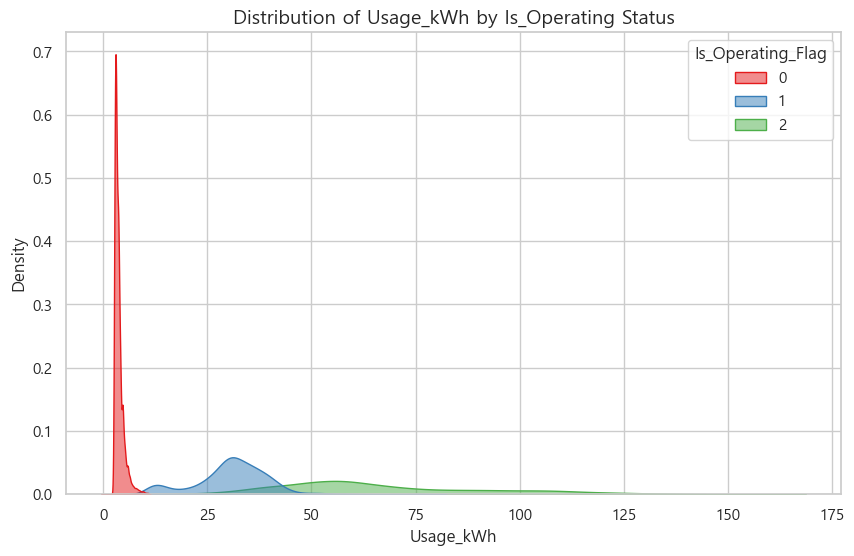

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Usage_kWh')

Text(0, 0.5, 'Is_Operating (0 or 1)')

Text(0.5, 1.0, 'Time-Series Alignment: 1 (Usage vs Operating Flag)')

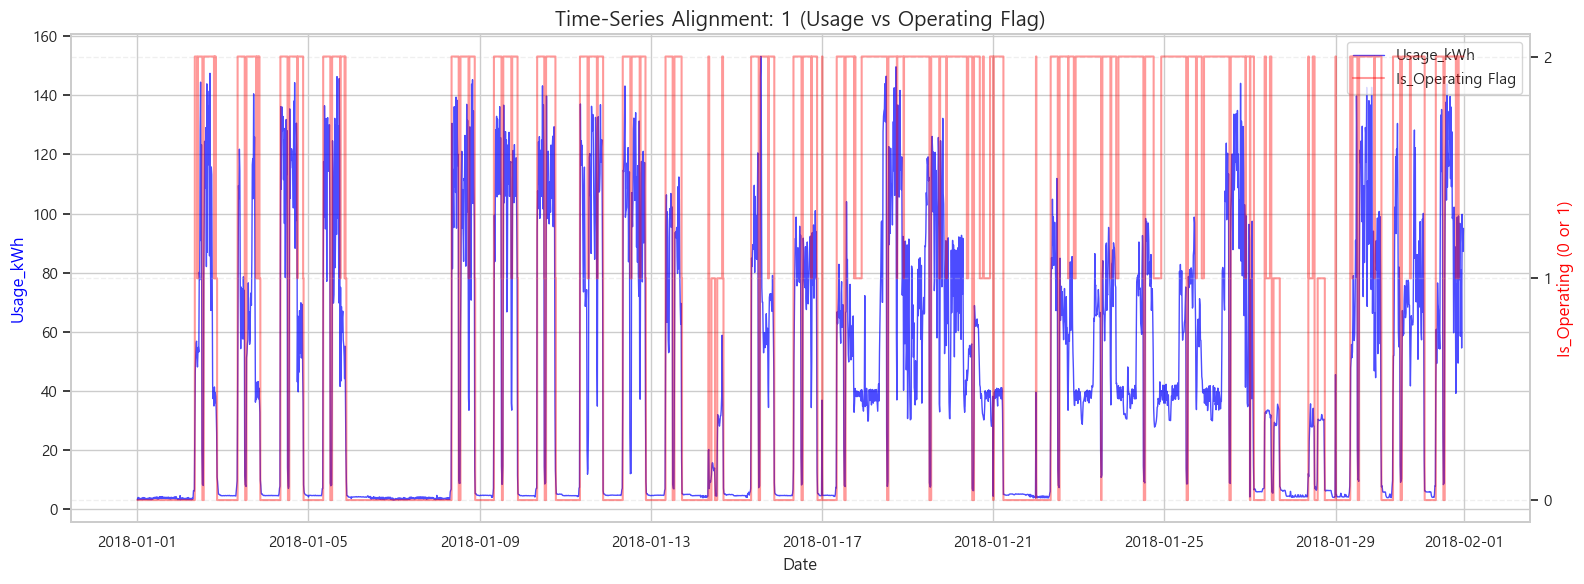

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Usage_kWh')

Text(0, 0.5, 'Is_Operating (0 or 1)')

Text(0.5, 1.0, 'Time-Series Alignment: 2 (Usage vs Operating Flag)')

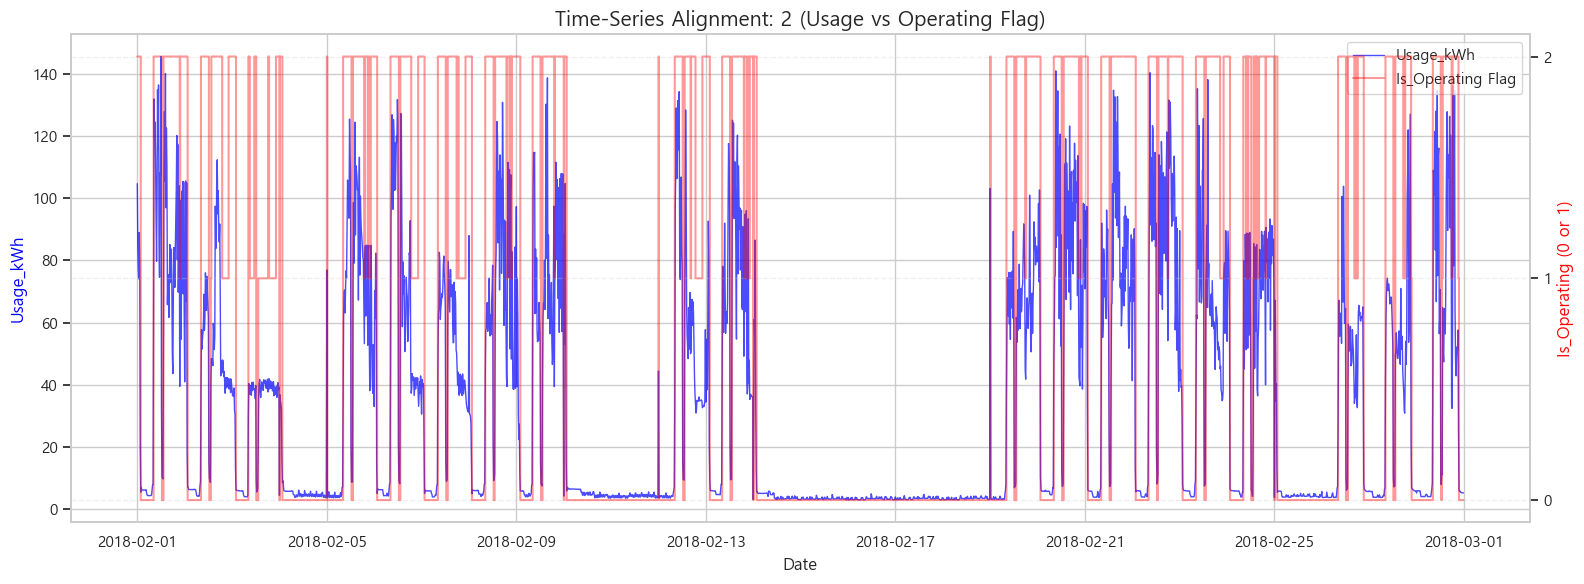

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Usage_kWh')

Text(0, 0.5, 'Is_Operating (0 or 1)')

Text(0.5, 1.0, 'Time-Series Alignment: 3 (Usage vs Operating Flag)')

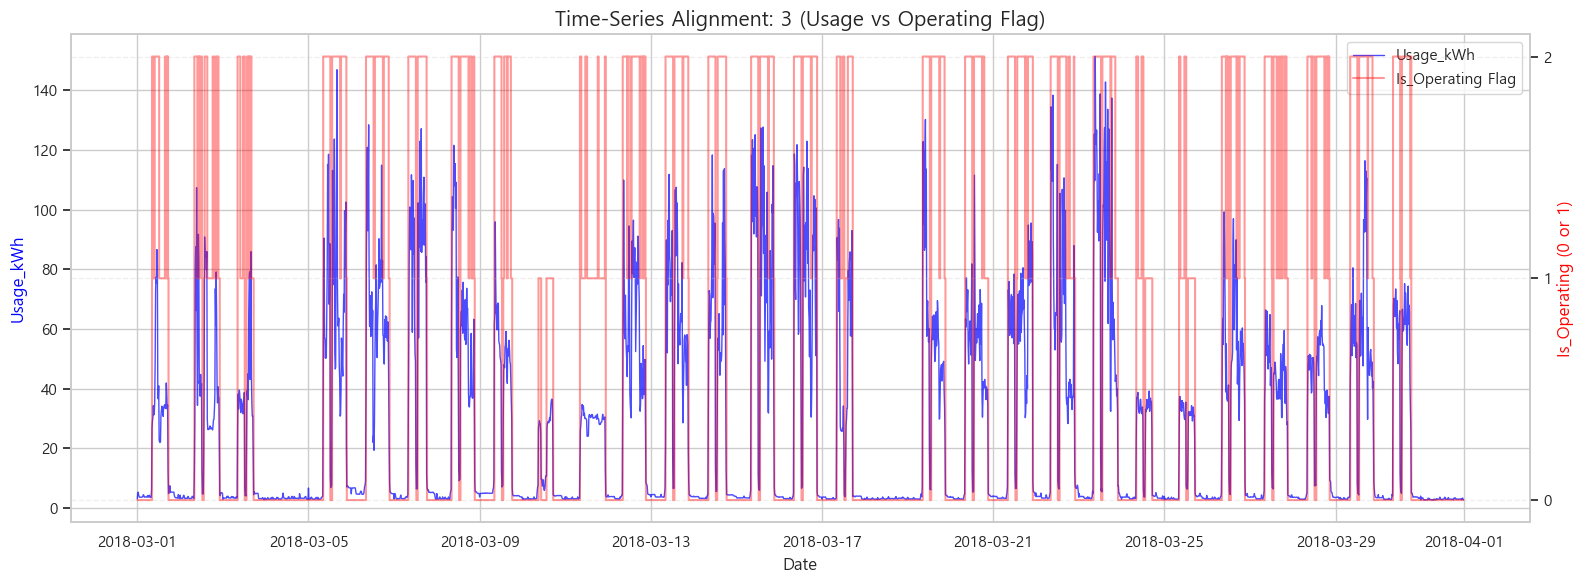

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Usage_kWh')

Text(0, 0.5, 'Is_Operating (0 or 1)')

Text(0.5, 1.0, 'Time-Series Alignment: 4 (Usage vs Operating Flag)')

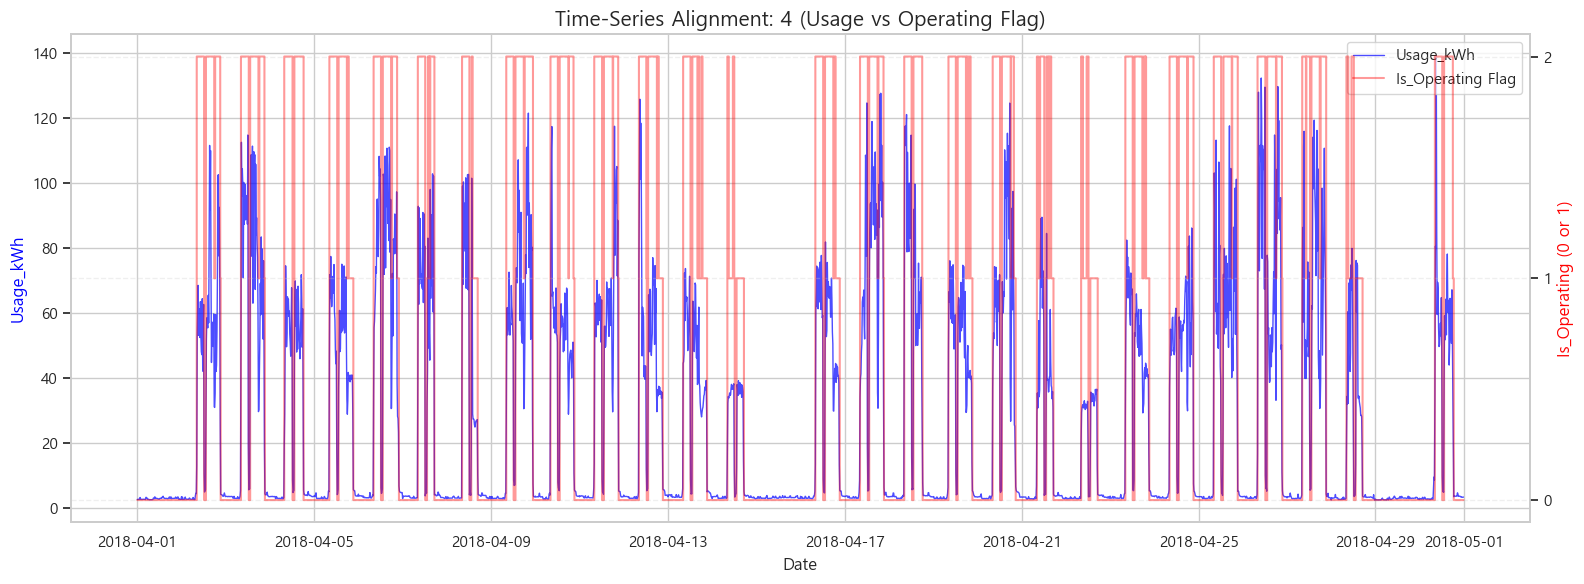

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Usage_kWh')

Text(0, 0.5, 'Is_Operating (0 or 1)')

Text(0.5, 1.0, 'Time-Series Alignment: 5 (Usage vs Operating Flag)')

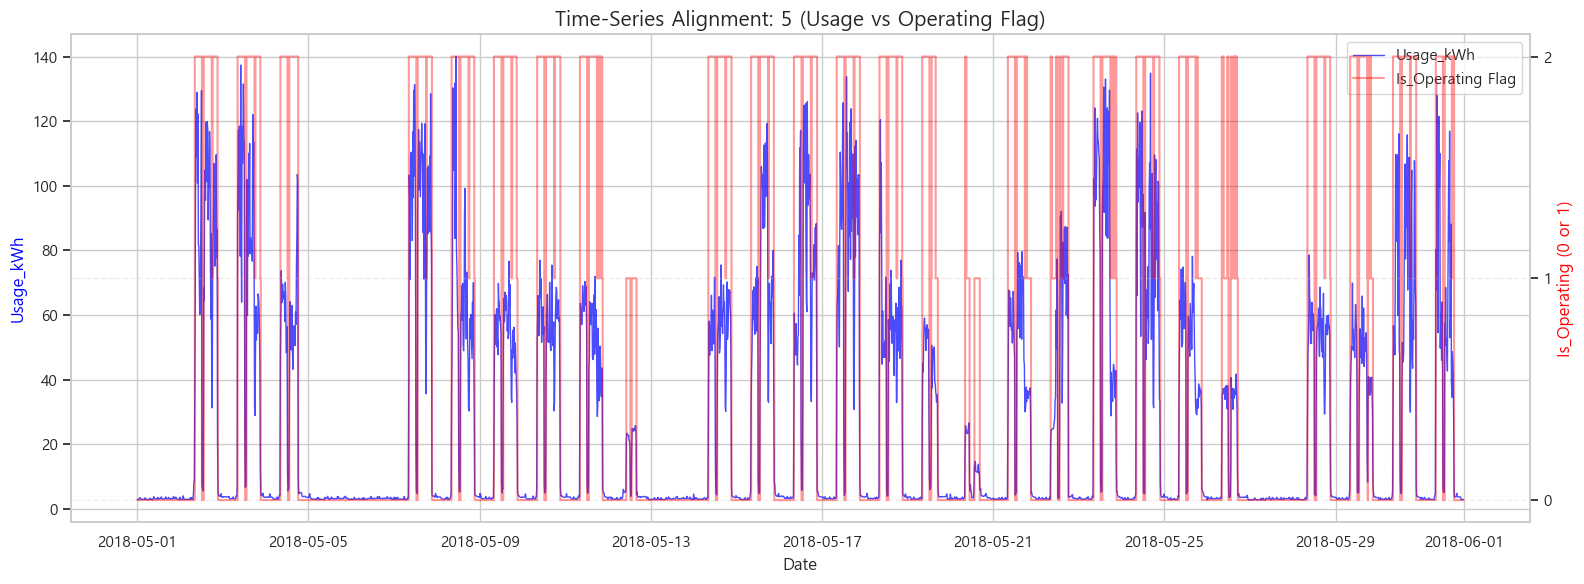

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Usage_kWh')

Text(0, 0.5, 'Is_Operating (0 or 1)')

Text(0.5, 1.0, 'Time-Series Alignment: 6 (Usage vs Operating Flag)')

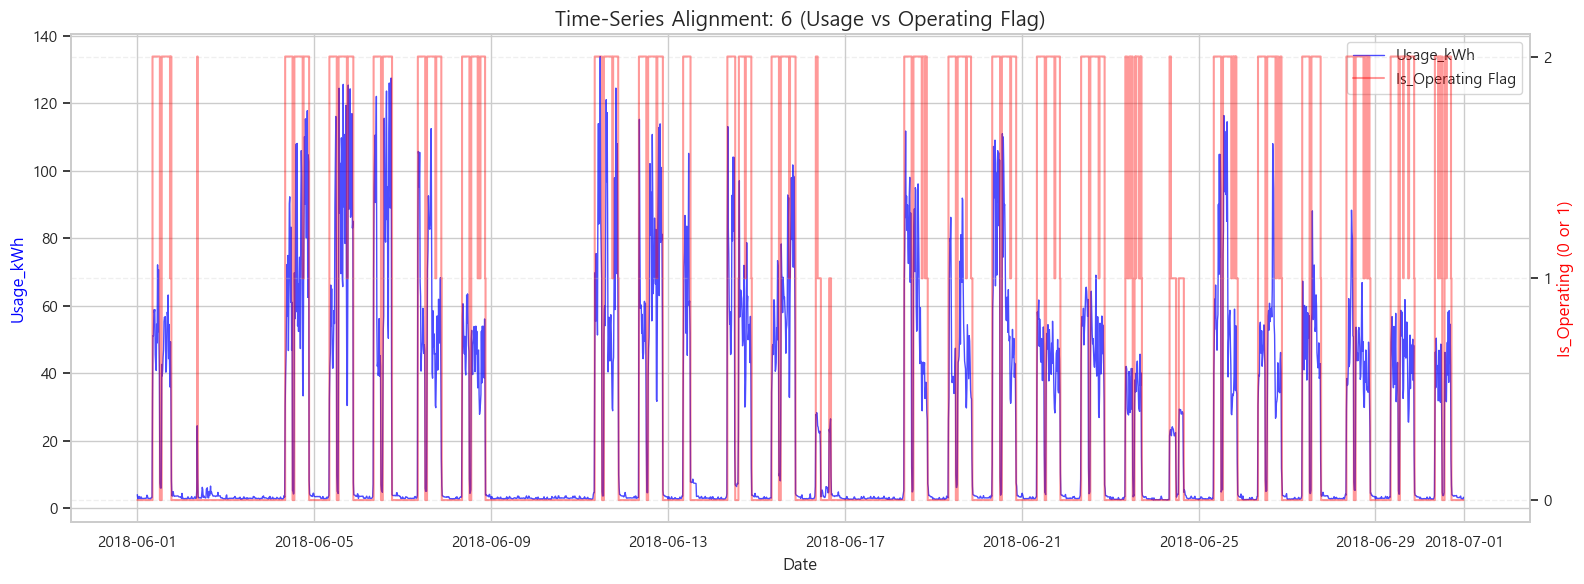

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Usage_kWh')

Text(0, 0.5, 'Is_Operating (0 or 1)')

Text(0.5, 1.0, 'Time-Series Alignment: 7 (Usage vs Operating Flag)')

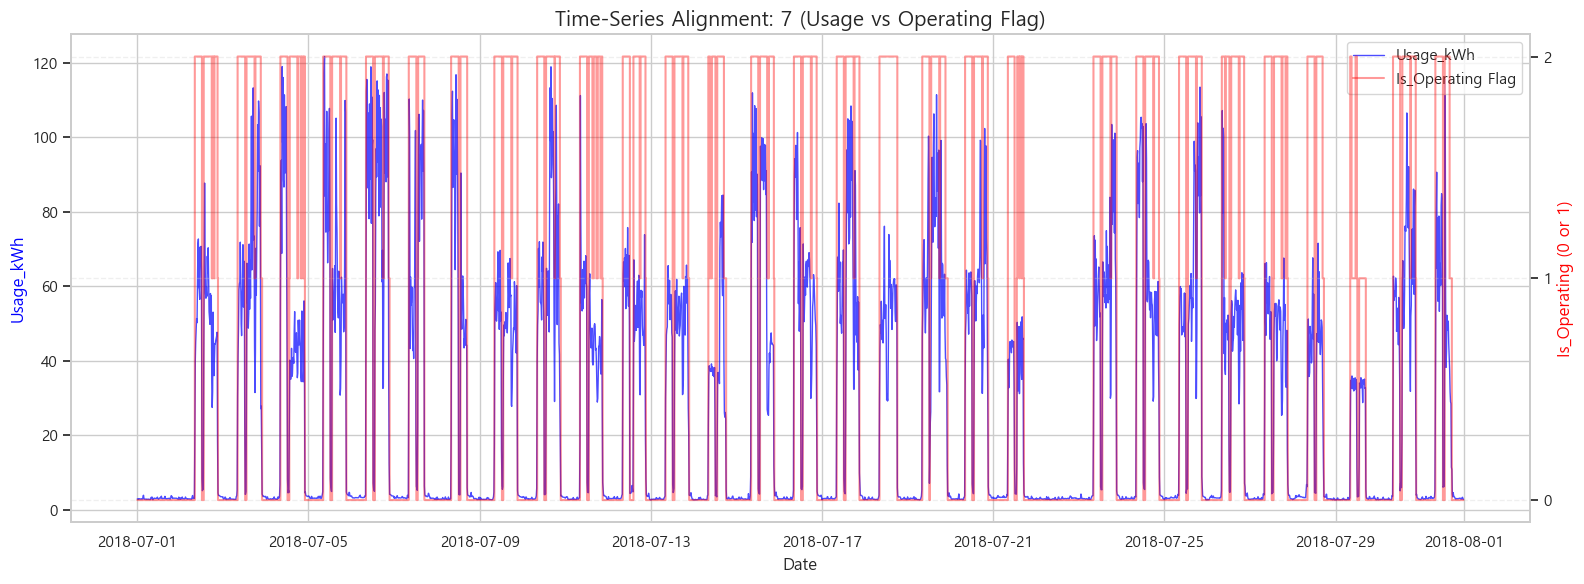

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Usage_kWh')

Text(0, 0.5, 'Is_Operating (0 or 1)')

Text(0.5, 1.0, 'Time-Series Alignment: 8 (Usage vs Operating Flag)')

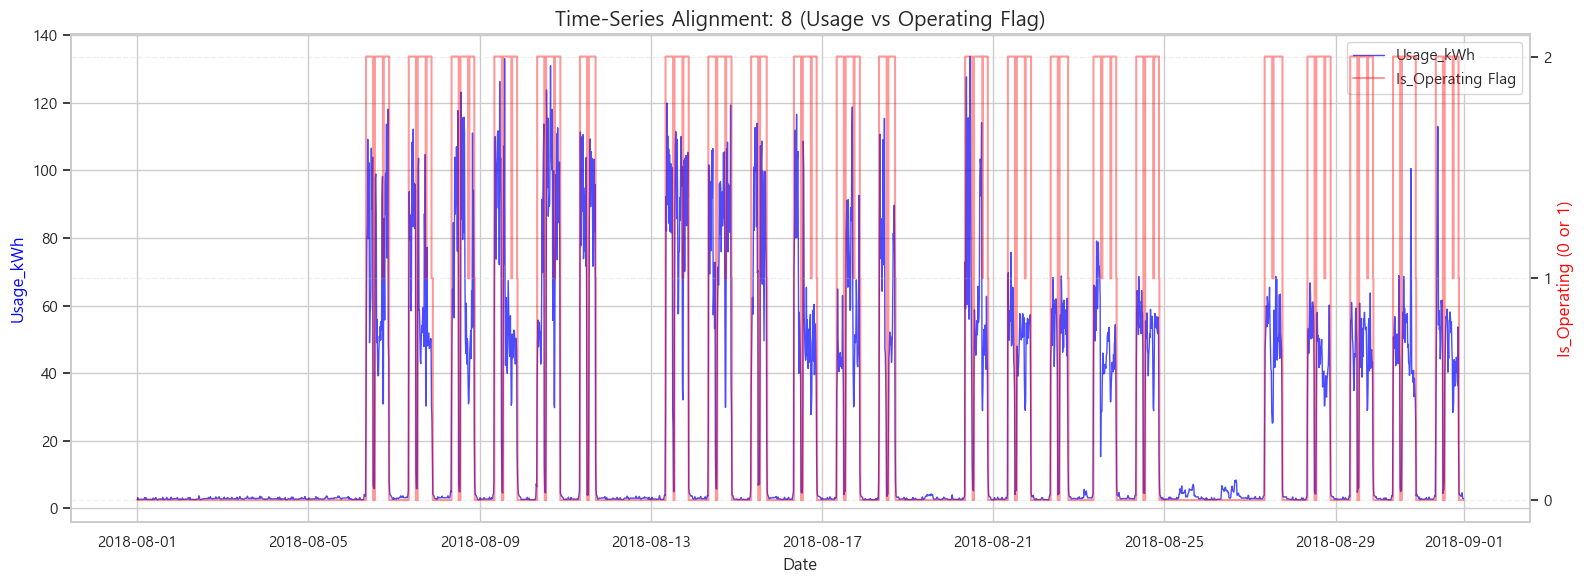

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Usage_kWh')

Text(0, 0.5, 'Is_Operating (0 or 1)')

Text(0.5, 1.0, 'Time-Series Alignment: 9 (Usage vs Operating Flag)')

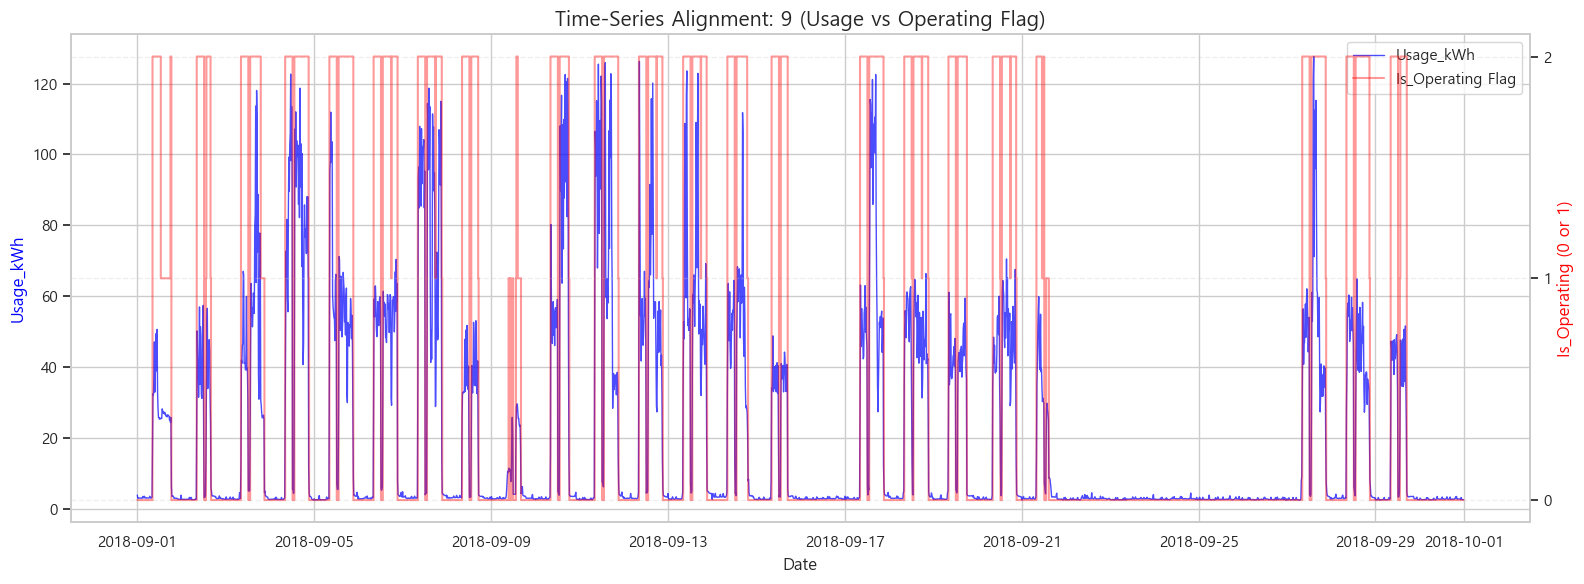

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Usage_kWh')

Text(0, 0.5, 'Is_Operating (0 or 1)')

Text(0.5, 1.0, 'Time-Series Alignment: 10 (Usage vs Operating Flag)')

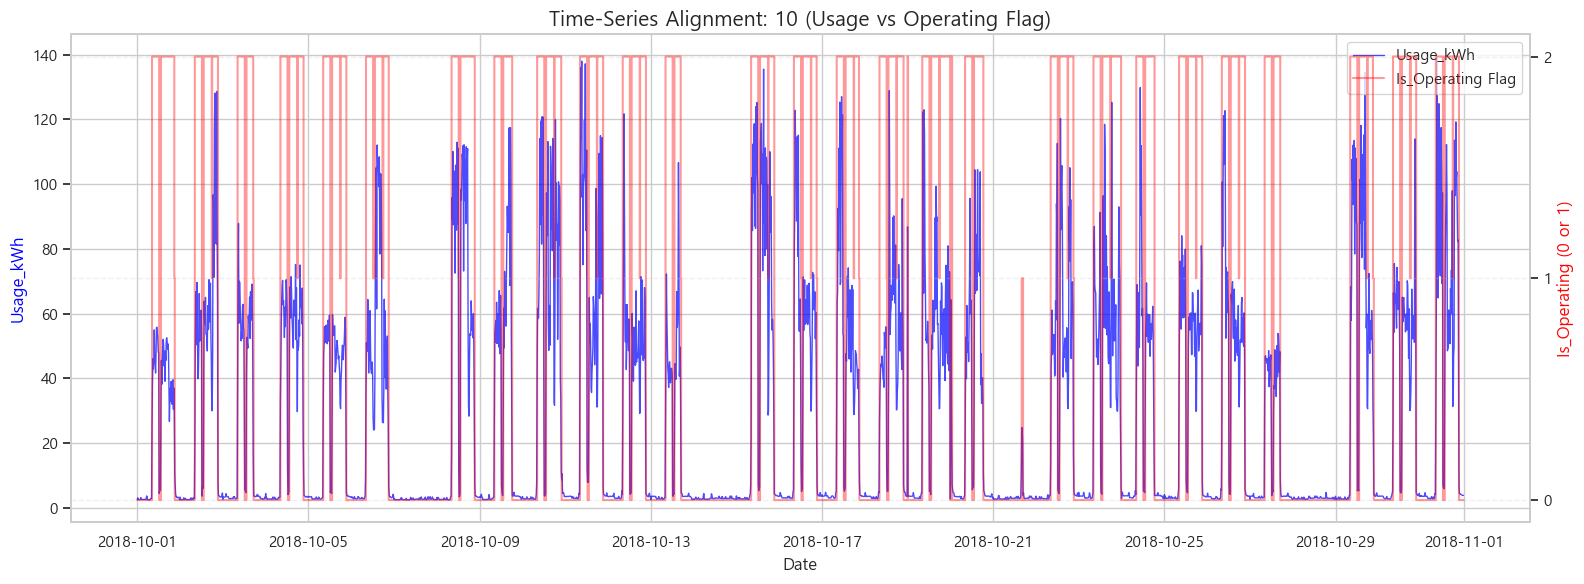

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Usage_kWh')

Text(0, 0.5, 'Is_Operating (0 or 1)')

Text(0.5, 1.0, 'Time-Series Alignment: 11 (Usage vs Operating Flag)')

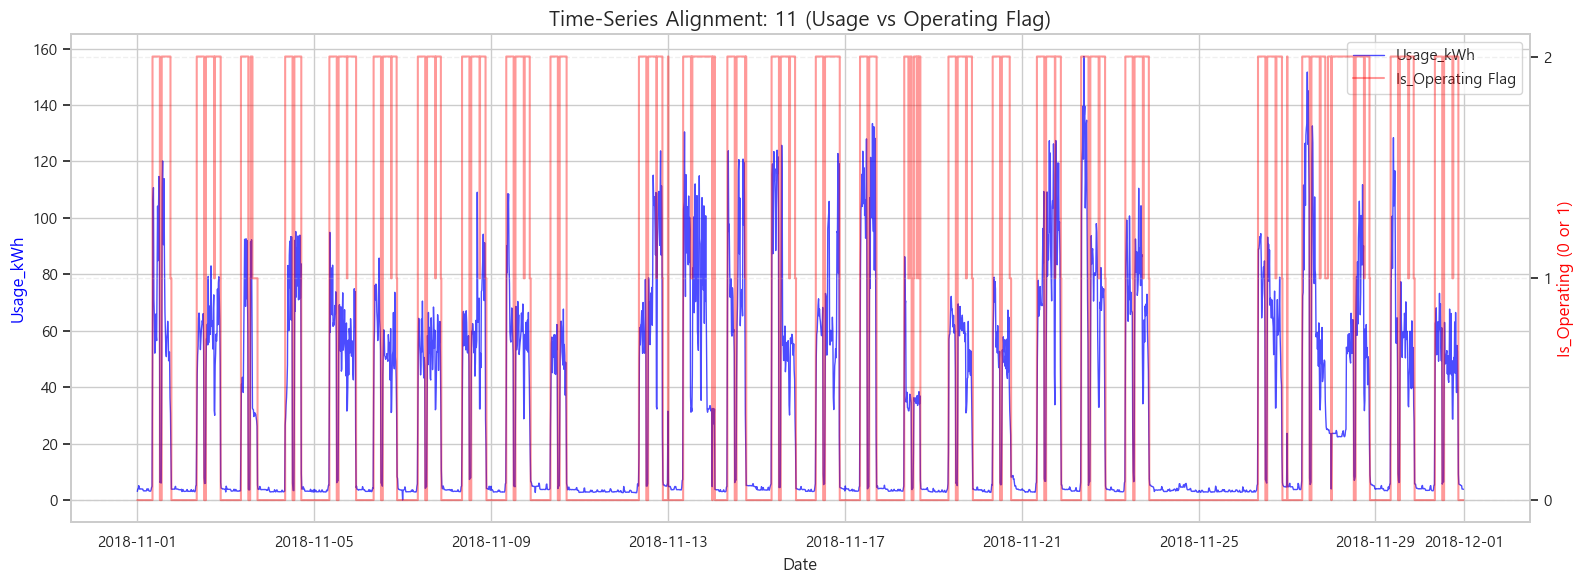

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Usage_kWh')

Text(0, 0.5, 'Is_Operating (0 or 1)')

Text(0.5, 1.0, 'Time-Series Alignment: 12 (Usage vs Operating Flag)')

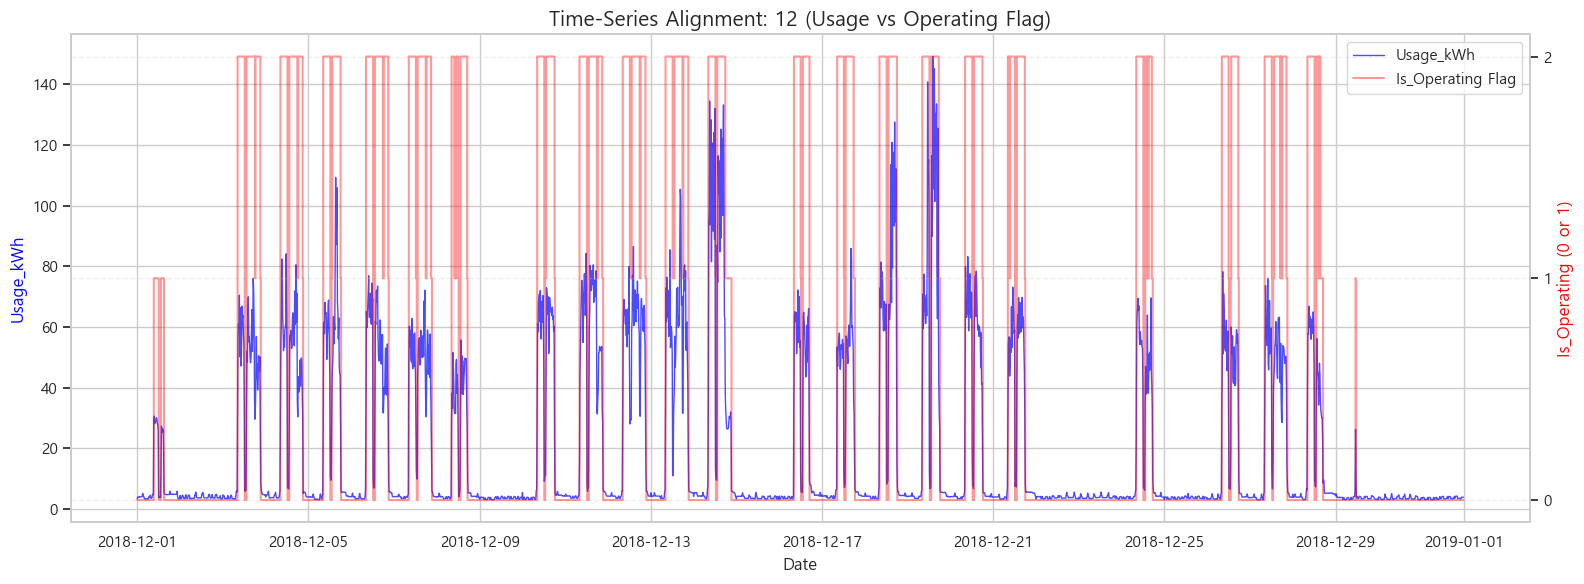

▶ 논리적 오류 1 (정지 상태이나 모터 가동됨): 14059건
▶ 논리적 오류 2 (가동 상태이나 전력 사용량 극단적 낮음): 0건

경고: Is_Operating 피처에 논리적 결함이 존재합니다. 산출 로직을 다시 확인하십시오.


In [15]:
# 1. 분포 분리 검증 (KDE Plot)
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='Usage_kWh', hue='Is_Operating_Flag', fill=True, common_norm=False, palette='Set1', alpha=0.5)
plt.title('Distribution of Usage_kWh by Is_Operating Status', fontsize=14)
plt.xlabel('Usage_kWh')
plt.ylabel('Density')
plt.show();

# 2. 시계열 정합성 검증

for month in [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12]:
    # 해당 월의 데이터 필터링
    sample_df = df[df['Month'] == month]
    
    fig, ax1 = plt.subplots(figsize=(16, 6))
    ax2 = ax1.twinx()

    # 전력 사용량 (Usage_kWh) - 선 그래프
    ax1.plot(sample_df['date'], sample_df['Usage_kWh'], color='blue', label='Usage_kWh', alpha=0.7, linewidth=1)
    
    # 가동 여부 플래그 (Is_Operating_Flag) - 계단식 그래프
    ax2.step(sample_df['date'], sample_df['Is_Operating_Flag'], color='red', label='Is_Operating Flag', alpha=0.4, where='post')

    # 축 설정
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Usage_kWh', color='blue', fontsize=12)
    ax2.set_ylabel('Is_Operating (0 or 1)', color='red', fontsize=12)
    ax2.set_yticks([0, 1, 2])
    
    plt.title(f'Time-Series Alignment: {month} (Usage vs Operating Flag)', fontsize=15)
    
    # 범례 통합 표시 (선택 사항)
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

    plt.grid(True, which='both', linestyle='--', alpha=0.3)
    plt.tight_layout()
    
    # 차트 저장 혹은 출력
    # plt.savefig(f'alignment_{month}.png') 
    plt.show();

# 3. 논리적 모순 데이터 검출 (Contradiction Check)
# 기준치(threshold)는 실제 공정의 기저 부하 수준에 맞춰 조정 필요
base_load_threshold = df['Usage_kWh'].quantile(0.05) + 2 # 예: 하위 5% 수준을 기저 부하로 가정

contradiction_1 = df[(df['Is_Operating_Flag'] == 0) & (df['Motor_Operating_Rate'] > 0.05)]
contradiction_2 = df[(df['Is_Operating_Flag'] == 1) & (df['Usage_kWh'] < base_load_threshold)]

print(f"▶ 논리적 오류 1 (정지 상태이나 모터 가동됨): {len(contradiction_1)}건")
print(f"▶ 논리적 오류 2 (가동 상태이나 전력 사용량 극단적 낮음): {len(contradiction_2)}건")

if len(contradiction_1) > 0 or len(contradiction_2) > 0:
    print("\n경고: Is_Operating 피처에 논리적 결함이 존재합니다. 산출 로직을 다시 확인하십시오.")

In [16]:
df.columns

Index(['date', 'Usage_kWh', 'Lagging_Current_Reactive_Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2_ppm',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
       'WeekStatus', 'Day_of_week', 'Load_Type', 'Hour', 'DayOfWeek', 'Month',
       'Year', 'Is_Weekend', 'Season', 'Month_sin', 'Month_cos',
       'DayOfWeek_sin', 'DayOfWeek_cos', 'Apparent_Power', 'PF_Physical',
       'Motor_Moving_Avg_1h_std', 'Motor_Operating_Rate',
       'Capacitor_Operating_Rate', 'Q_total_abs', 'Motor_Ratio',
       'Capacitor_Ratio', 'Over_Correction_Flag', 'Is_Operating_Flag'],
      dtype='object')

# 변수 전반에 대한 EDA

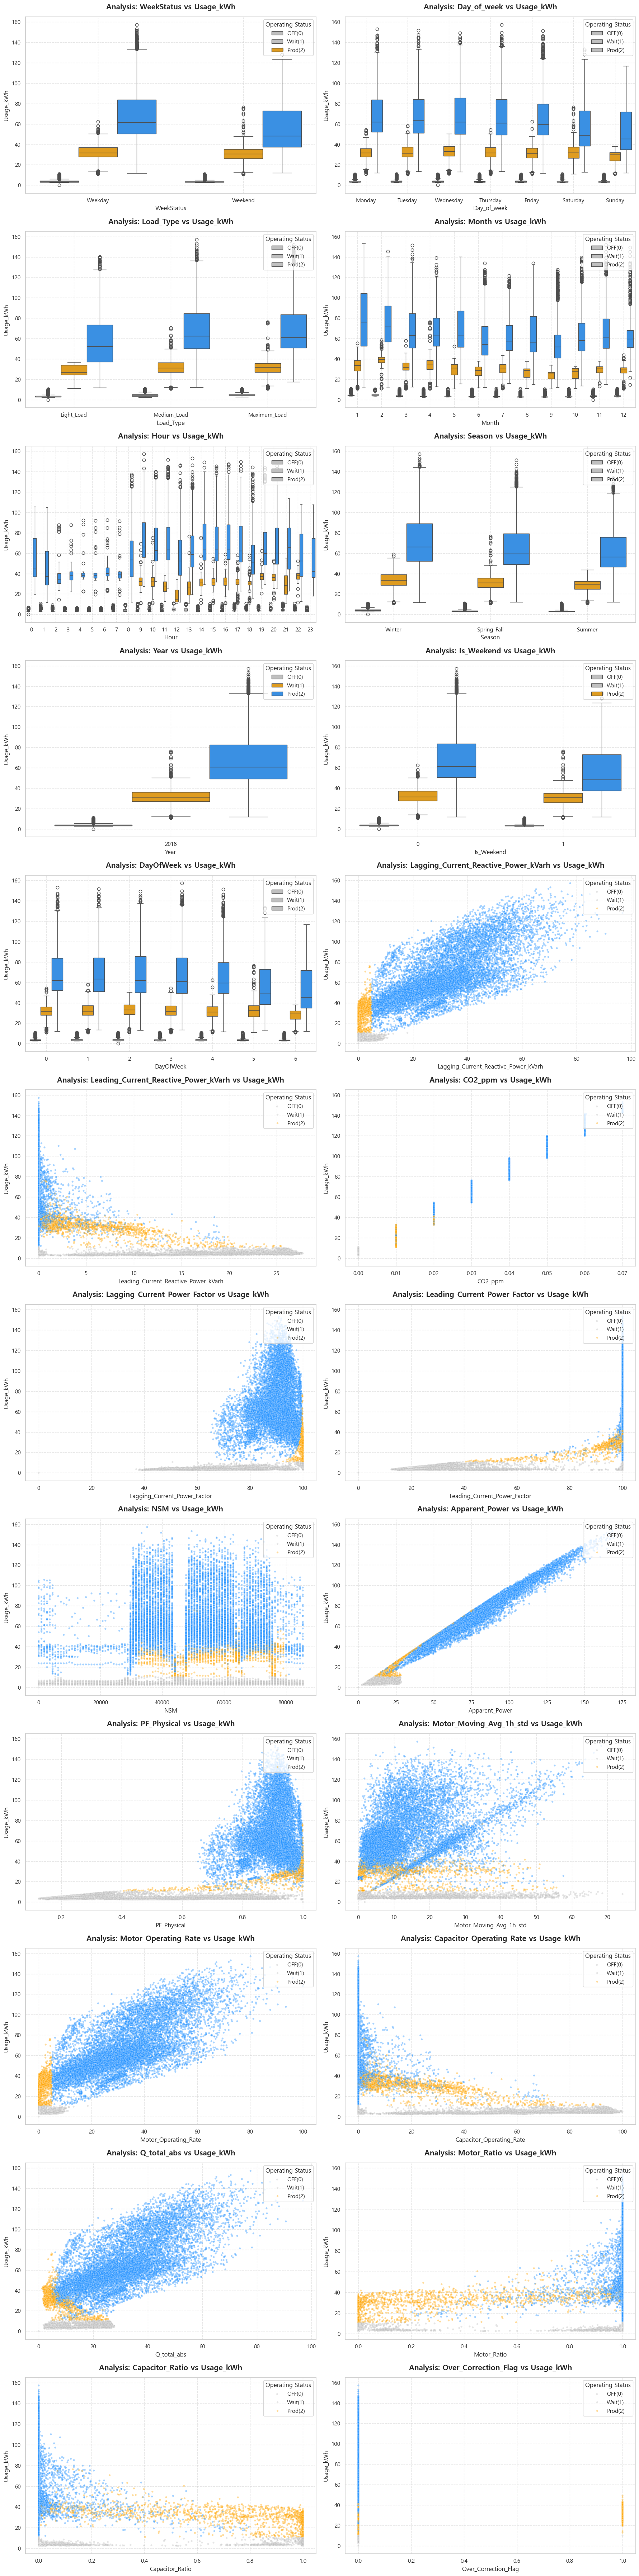

In [17]:
# 1. 컬럼 분류 (제공해주신 Index 기준으로 현행화)
cat_cols = ['WeekStatus', 'Day_of_week', 'Load_Type', 'Month', 'Hour', 'Season', 'Year', 'Is_Weekend', 'DayOfWeek'] 
num_cols = [
    'Lagging_Current_Reactive_Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 
    'CO2_ppm', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 
    'NSM', 'System_Stress_Load', 'Reactive_Intensity', 'Apparent_Power', 
    'PF_Physical', 'Motor_Moving_Avg_1h_std', 'Motor_Operating_Rate', 
    'Capacitor_Operating_Rate', 'Q_total_abs', 'Motor_Ratio', 'Capacitor_Ratio',
    'Over_Correction_Flag', 'Production_Capacity_Pct'
]

# 2. 변수 선언
target = 'Usage_kWh'
split_by = 'Is_Operating_Flag'  # 3단계 상태 변수명으로 수정
data_source = df

# target과 split_by, 그리고 시계열(date) 제외한 피처 리스트 생성
all_target_cols = [c for c in (cat_cols + num_cols) if c in df.columns and c not in [target, split_by, 'date']]

# 3. 실행 로직
nrows = (len(all_target_cols) + 1) // 2
fig, axes = plt.subplots(nrows=nrows, ncols=2, figsize=(18, 6 * nrows))
axes = axes.flatten()

# 3단계 상태에 대한 명확한 컬러 맵 지정 (0:Grey, 1:Orange, 2:Blue)
custom_palette = {0: 'silver', 1: 'orange', 2: 'dodgerblue'}

for i, col in enumerate(all_target_cols):
    ax = axes[i]
    
    if col in cat_cols:
        # 범주형: Boxplot (상태별 분포 비교)
        sns.boxplot(data=data_source, x=col, y=target, hue=split_by, ax=ax, palette=custom_palette)
    else:
        # 수치형: Scatterplot (군집 및 상관관계 확인)
        sns.scatterplot(data=data_source, x=col, y=target, hue=split_by, ax=ax, alpha=0.4, palette=custom_palette, s=15)

    ax.set_title(f'Analysis: {col} vs {target}', fontsize=15, fontweight='bold', pad=15)
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel(target, fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)

    if ax.get_legend() is not None:
        ax.legend(title='Operating Status', loc='upper right', labels=['OFF(0)', 'Wait(1)', 'Prod(2)'])

# 남는 빈 서브플롯 제거
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show();

## 히트맵 분석

In [18]:
df.columns

Index(['date', 'Usage_kWh', 'Lagging_Current_Reactive_Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2_ppm',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
       'WeekStatus', 'Day_of_week', 'Load_Type', 'Hour', 'DayOfWeek', 'Month',
       'Year', 'Is_Weekend', 'Season', 'Month_sin', 'Month_cos',
       'DayOfWeek_sin', 'DayOfWeek_cos', 'Apparent_Power', 'PF_Physical',
       'Motor_Moving_Avg_1h_std', 'Motor_Operating_Rate',
       'Capacitor_Operating_Rate', 'Q_total_abs', 'Motor_Ratio',
       'Capacitor_Ratio', 'Over_Correction_Flag', 'Is_Operating_Flag'],
      dtype='object')

In [19]:
# 학습에 사용할 '오염되지 않은' 피처 리스트
features = [
    'Hour', 
    'Is_Weekend', 
    'Month_sin', 
    'Month_cos', 
    'DayOfWeek_sin', 
    'DayOfWeek_cos', 
    'Motor_Operating_Rate',         # 핵심 제어 변수 1
    'Capacitor_Operating_Rate',     # 핵심 제어 변수 2
    'Is_Operating_Flag',            # (수정됨) 모터 가동률 기반 플래그
    'Motor_Moving_Avg_1h_std'       # (수정됨) 모터 가동 변동성
]

# 타겟 변수
target_usage = 'Usage_kWh'
target_pf = 'PF_Physical'

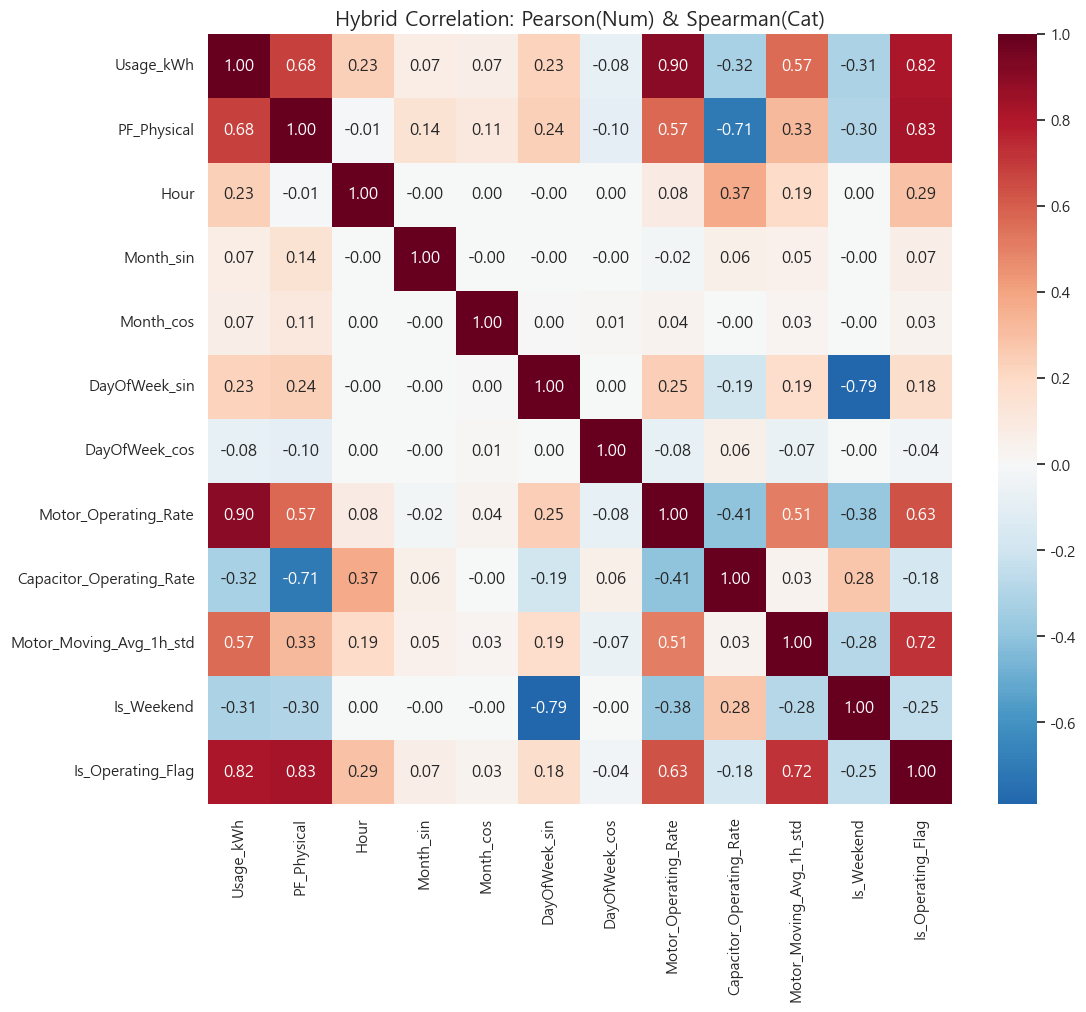

In [20]:
# 1. 사용자가 직접 컬럼 성격 분류 (가장 확실한 방법)
cat_cols = ['Is_Weekend', 'Is_Operating_Flag']  # 범주형
num_cols = ['Usage_kWh', 'PF_Physical', 
            'Hour', 
            'Month_sin', 
            'Month_cos', 
            'DayOfWeek_sin', 
            'DayOfWeek_cos', 
            'Motor_Operating_Rate',         # 핵심 제어 변수 1
            'Capacitor_Operating_Rate',     # 핵심 제어 변수 2
            'Motor_Moving_Avg_1h_std'
           ]

# 1. 계산 로직을 담은 함수 (df 언급 최소화용)
def calculate_hybrid_corr(df, num_cols, cat_cols):
    all_cols = num_cols + cat_cols
    # 범주형 컬럼만 임시로 숫자로 변환 (Factorize)
    temp_df = df[all_cols].copy()
    for col in cat_cols:
        temp_df[col] = temp_df[col].factorize()[0]
    
    # 빈 행렬 생성
    corr_matrix = pd.DataFrame(index=all_cols, columns=all_cols)
    
    for c1 in all_cols:
        for c2 in all_cols:
            # 하나라도 범주형이면 spearman, 둘 다 수치형이면 pearson
            method = 'spearman' if (c1 in cat_cols or c2 in cat_cols) else 'pearson'
            corr_matrix.loc[c1, c2] = temp_df[c1].corr(temp_df[c2], method=method)
            
    return corr_matrix.astype(float)

# 2. 통합 실행부 (raw_data는 여기서 딱 한 번만 언급)
integrated_corr = df.pipe(calculate_hybrid_corr, num_cols=num_cols, cat_cols=cat_cols)

# 3. 시각화
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(integrated_corr, dtype=bool))
sns.heatmap(integrated_corr, annot=True, fmt=".2f", cmap='RdBu_r', center=0)
plt.title('Hybrid Correlation: Pearson(Num) & Spearman(Cat)', fontsize=15)
plt.show();

# Surrogate Model(최적화를 위한 전력 사용량, 실시간 역률 추정)

## 모델 훈련

In [21]:
# 2. 데이터 타입 업데이트 (객체 참조 1회 사용)
target_df = df.copy() # 혹은 학습용 원본 df

# 범주형 컬럼을 category 타입으로 변환 (XGBoost 학습 최적화)
cat_features = ['Hour', 'Is_Weekend', 'Is_Operating_Flag']
for col in cat_features:
    target_df[col] = target_df[col].astype('category')

print("학습용 피처 선정이 완료되었습니다. 범주형 데이터가 'category' 타입으로 업데이트되었습니다.")

# 2. 시계열 분할 (2017년 데이터 기준 상위 80% 학습, 하위 20% 검증)
split_idx = int(len(target_df) * 0.8)
train_df = target_df.iloc[:split_idx]
test_df = target_df.iloc[split_idx:]

X_train, y_train_usage = train_df[features], train_df[target_usage]
X_test, y_test_usage = test_df[features], test_df[target_usage]

y_train_pf = train_df[target_pf]
y_test_pf = test_df[target_pf]
# 3. 모델 정의 및 학습 (기본 파라미터 설정)
# 1. 단조 제약(Monotonic Constraints) 설정 
# (모터 가동률과 콘덴서 가동률이 오르면 전력도 무조건 오른다는 물리적 제약 1 부여)
monotone_constraints = {f: 1 if 'Operating_Rate' in f else 0 for f in features}

weights = np.ones(len(X_train))
weights[(X_train['Motor_Operating_Rate'] > 75) & (X_train['Hour'] < 8)] *= 2.0

# 1. 전력 사용량(Usage) 예측 모델
model_usage = xgb.XGBRegressor(
    n_estimators=1500, # 트리 개수 증가
    learning_rate=0.03, # 학습률을 낮춰 더 세밀하게 학습
    max_depth=5, # [핵심] 깊이를 늘려 75~100% 구간 강제 분할
    subsample=0.8,
    colsample_bytree=0.4, # [핵심] 0.8 -> 0.4로 낮춤 (Flag 변수 의존도 강제 축소)
    n_jobs=-1,
    random_state=42,
    enable_categorical=True,
    monotone_constraints=monotone_constraints, # [핵심] 물리 법칙 강제
    early_stopping_rounds=50,
    sample_weight=weights
)
model_usage.fit(X_train, y_train_usage, eval_set=[(X_test, y_test_usage)], verbose=False)

# 2. 역률(PF) 예측 모델
model_pf = xgb.XGBRegressor(
    n_estimators=1500, # 트리 개수 증가
    learning_rate=0.03, # 학습률을 낮춰 더 세밀하게 학습
    max_depth=5, # [핵심] 깊이를 늘려 75~100% 구간 강제 분할
    subsample=0.8,
    colsample_bytree=0.4, # [핵심] 0.8 -> 0.4로 낮춤 (Flag 변수 의존도 강제 축소)
    n_jobs=-1,
    random_state=42,
    enable_categorical=True,
    monotone_constraints=monotone_constraints, # [핵심] 물리 법칙 강제
    early_stopping_rounds=50
)
model_pf.fit(X_train, y_train_pf, eval_set=[(X_test, y_test_pf)], verbose=False)

# 4. 성능 평가
preds = model_usage.predict(X_test)
print(f"MAE: {mean_absolute_error(y_test_usage, preds):.4f}")
print(f"R2 Score: {r2_score(y_test_usage, preds):.4f}")

# 4. 성능 평가
preds_PF = model_pf.predict(X_test)
print(f"MAE: {mean_absolute_error(y_test_pf, preds_PF):.4f}")
print(f"R2 Score: {r2_score(y_test_pf, preds_PF):.4f}")

학습용 피처 선정이 완료되었습니다. 범주형 데이터가 'category' 타입으로 업데이트되었습니다.


TypeError: Unordered Categoricals can only compare equality or not

## 훈련모델 피쳐 importance 확인

In [ ]:
# 피처 중요도 확인 (텍스트 출력)
importances = pd.Series(model_usage.feature_importances_, index=features).sort_values(ascending=False)

print("\n=== Feature Importance Top 5 ===")
print(importances.head(5))

# 1. 정렬된 데이터를 변수에 저장
top_features = importances.sort_values(ascending=False).head(10)

# 2. 그래프 그리기
plt.figure(figsize=(12, 6))
plt.title("Usage Feature Importances")

# x에는 중요도 수치(values), y에는 피처 이름(index)을 직접 전달
sns.barplot(x=top_features.values, y=top_features.index, palette='magma')

plt.xlabel("Relative Importance")
plt.tight_layout()
plt.show();

In [ ]:
# 피처 중요도 확인 (텍스트 출력)
importances = pd.Series(model_pf.feature_importances_, index=features).sort_values(ascending=False)

print("\n=== Feature Importance Top 5 ===")
print(importances.head(5))

# 1. 정렬된 데이터를 변수에 저장
top_features = importances.sort_values(ascending=False).head(10)

# 2. 그래프 그리기
plt.figure(figsize=(12, 6))
plt.title("PF Feature Importances")

# x에는 중요도 수치(values), y에는 피처 이름(index)을 직접 전달
sns.barplot(x=top_features.values, y=top_features.index, palette='magma')

plt.xlabel("Relative Importance")
plt.tight_layout()
plt.show();

## surrogate model의 민감도 확인

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def test_model_sensitivity(model_usage, features):
    # 가상의 기본 상태 세팅 (조업 중인 평일 낮 시간 가정)
    test_data = {f: 0 for f in features}
    
    # 범주형/환경 변수 고정 (예: Flag=2 (고전력 기동))
    if 'Hybrid_Operating_Flag' in features: test_data['Hybrid_Operating_Flag'] = 2
    elif 'Is_Operating_Flag' in features: test_data['Is_Operating_Flag'] = 2
    
    # 모터 가동률을 10%부터 100%까지 1%씩 연속적으로 변화시키며 예측
    motor_rates = np.linspace(10, 100, 91)
    predictions = []
    
    motor_idx = features.index('Motor_Operating_Rate')
    base_array = np.array([list(test_data.values())])
    
    for rate in motor_rates:
        temp_array = base_array.copy()
        temp_array[0, motor_idx] = rate
        pred = model_usage.predict(temp_array)[0]
        predictions.append(pred)
        
    plt.figure(figsize=(10, 5))
    plt.plot(motor_rates, predictions, color='royalblue', linewidth=2, marker='o', markersize=3)
    plt.title("Surrogate Model Sensitivity Check: Usage_kWh vs Motor Rate", fontsize=14)
    plt.xlabel("Motor_Operating_Rate (%)", fontsize=12)
    plt.ylabel("Predicted Usage (kWh)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

# 함수 실행
test_model_sensitivity(model_usage, features)

In [ ]:
# 모터 가동률 구간별 데이터 개수 확인
bins = [0, 25, 50, 75, 100]
print("=== 모터 가동률 구간별 데이터 분포 ===")
print(pd.cut(df['Motor_Operating_Rate'], bins=bins).value_counts())

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def test_pf_sensitivity(model_pf, features):
    # 가상의 기본 상태 세팅 (모터가 50%로 강하게 돌아가고 있는 상태 가정)
    test_data = {f: 0 for f in features}
    
    if 'Hybrid_Operating_Flag' in features: test_data['Hybrid_Operating_Flag'] = 2
    elif 'Is_Operating_Flag' in features: test_data['Is_Operating_Flag'] = 2
    
    # 인덱스 추출
    motor_idx = features.index('Motor_Operating_Rate')
    cap_idx = features.index('Capacitor_Operating_Rate')
    
    base_array = np.array([list(test_data.values())], dtype=float)
    base_array[0, motor_idx] = 50.0  # 모터 가동률을 50%로 고정 (지상 무효전력 발생)
    
    # 콘덴서 가동률을 0%에서 100%까지 변화시키며 역률 예측
    cap_rates = np.linspace(0, 100, 51)
    predictions = []
    
    for rate in cap_rates:
        temp_array = base_array.copy()
        temp_array[0, cap_idx] = rate
        pred = model_pf.predict(temp_array)[0]
        predictions.append(pred)
        
    # 시각화
    plt.figure(figsize=(10, 5))
    plt.plot(cap_rates, predictions, color='darkorange', linewidth=2, marker='D', markersize=4)
    
    # 한전 페널티 기준선 및 최대 역률선 표시
    plt.axhline(y=0.92, color='red', linestyle='--', linewidth=2, label='KEPCO Target (0.92)')
    plt.axhline(y=1.00, color='grey', linestyle=':', linewidth=2, label='Ideal PF (1.00)')
    
    plt.title("PF Surrogate Model Sensitivity: Capacitor Rate vs Predicted PF", fontsize=14, fontweight='bold')
    plt.xlabel("Capacitor_Operating_Rate (%)", fontsize=12)
    plt.ylabel("Predicted Power Factor (0~1.0)", fontsize=12)
    plt.ylim(min(predictions) - 0.05, 1.05)
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

# 함수 실행
test_pf_sensitivity(model_pf, features)

# 공정 최적화

## 최적화 함수 생성

In [ ]:
max_lagging, max_leading

In [ ]:
import numpy as np
import pandas as pd
import time
import json
import optuna
from tqdm.auto import tqdm  # 진행률 바 생성을 위한 라이브러리 추가

# Optuna 로그 숨기기 (루프 내에서 너무 많은 출력이 발생하는 것 방지)
optuna.logging.set_verbosity(optuna.logging.WARNING)

class HybridFastSimulator:
    def __init__(self, model_usage, model_pf, features, json_config_path, max_lagging, max_leading):
        self.model_usage = model_usage
        self.model_pf = model_pf
        self.features = features
        self.max_lagging = max_lagging    # 방향 판별용 상수 1
        self.max_leading = max_leading    # 방향 판별용 상수 2
        
        # 요금제 JSON 로드
        with open(json_config_path, 'r', encoding='utf-8') as f:
            self.config = json.load(f)
            
    def _get_tou_price(self, scenario, month, hour):
        """계절 및 시간대별 전력 단가와 TOU 타입(off, mid, peak) 반환"""
        # 계절 판별 (기존 로직과 동일하게 유지)
        if month in [6, 7, 8]: season = 'summer'
        elif month in [11, 12, 1, 2]: season = 'winter'
        else: season = 'spring_fall'
            
        schedule = scenario['tou_schedule'][season]
        prices = scenario['unit_prices'][season]
        
        for tou_type, time_ranges in schedule.items():
            for start, end in time_ranges:
                # 야간 시간대(예: 22~8)가 자정을 넘기는 경우 처리
                if start > end:
                    if hour >= start or hour < end:
                        return prices[tou_type], tou_type
                else:
                    if start <= hour < end:
                        return prices[tou_type], tou_type
        return prices['off'], 'off' # 기본값

    def precompute_grid(self, df):
        """1단계: 전체 시간에 대한 그리드 배치 추론 (연산 속도의 핵심)"""
        print("⏳ 1단계: 대리 모델(XGBoost) 기반 35,040시간 가동률 그리드 사전 연산 중...")
        start_time = time.time()
        
        # 그리드 해상도: 모터 5% 단위 (21개), 콘덴서 10% 단위 (11개) -> 총 231개 조합
        self.motor_rates = np.linspace(0, 100, 101)
        self.cap_rates = np.linspace(0, 100, 11)
        M_grid, C_grid = np.meshgrid(self.motor_rates, self.cap_rates, indexing='ij')
        self.M_flat = M_grid.flatten()
        self.C_flat = C_grid.flatten()
        
        num_combinations = len(self.M_flat)
        N = len(df)
        
        self.usage_matrix = np.zeros((N, num_combinations))
        self.pf_matrix = np.zeros((N, num_combinations))
        self.q_sign_matrix = np.zeros((N, num_combinations))  # 물리적 부호(+/-) 저장
        
        X_base = df[self.features].values
        m_idx = self.features.index('Motor_Operating_Rate')
        c_idx = self.features.index('Capacitor_Operating_Rate')
        
        # tqdm 적용: 사전 연산 조합 진행률 표시
        for i in tqdm(range(num_combinations), desc="Grid Precomputing", unit="comb"):
            X_temp = X_base.copy()
            X_temp[:, m_idx] = self.M_flat[i]
            X_temp[:, c_idx] = self.C_flat[i]
            
            # 예측 수행
            self.usage_matrix[:, i] = self.model_usage.predict(X_temp)
            self.pf_matrix[:, i] = self.model_pf.predict(X_temp)

            # 2. 부호(방향) 판별기: 지상(+)인지 진상(-)인지만 물리 수식으로 계산
            q_lag = (self.M_flat[i] / 100.0) * self.max_lagging
            q_lead = (self.C_flat[i] / 100.0) * self.max_leading
            self.q_sign_matrix[:, i] = np.sign(q_lag - q_lead)
            
        print(f"✅ 사전 연산 완료! (소요 시간: {time.time() - start_time:.2f}초)")

    def fine_tune_optuna(self, X_row, m_idx, c_idx, base_m, base_c, current_price, target_prod, target_pf, is_lag_period, cum_kWh, cum_q):
        """2단계: 그리드에서 찾은 최적점 주변을 베이지안으로 미세 조정"""
        def objective(trial):
            # 그리드 최적점 주변 ±2.5% 범위 내에서 정밀 탐색
            m_rate = trial.suggest_float('m_rate', max(target_prod, base_m - 2.5), min(100.0, base_m + 2.5))
            c_rate = trial.suggest_float('c_rate', max(0.0, base_c - 5.0), min(100.0, base_c + 5.0))
            
            X_temp = X_row.copy()
            X_temp[m_idx] = m_rate
            X_temp[c_idx] = c_rate
            
            # 단일 행 예측 시 2D 배열 형태로 변환 필요
            usage = self.model_usage.predict(X_temp.reshape(1, -1))[0]
            pf_val = self.model_pf.predict(X_temp.reshape(1, -1))[0]
            pf_val = np.clip(pf_val, -1.0, 1.0)

            # AI의 예측 역률(PF)로부터 순간 무효전력(kVarh) 물리적 역산
            q_mag = usage * np.sqrt(max(0, 1.0 / (pf_val**2 + 1e-9) - 1.0))

            # 부호 판별
            q_lag_opt = (m_rate / 100.0) * self.max_lagging
            q_lead_opt = (c_rate / 100.0) * self.max_leading
            is_lagging_state = (q_lag_opt - q_lead_opt) >= 0

            # 평가 대상 무효전력 필터링
            q_eval = q_mag if (is_lag_period and is_lagging_state) or (not is_lag_period and not is_lagging_state) else 0.0

            # 🚀 [핵심 1] 월 누적 역률(Projected Cumulative PF) 계산
            proj_cum_kWh = cum_kWh + usage
            proj_cum_q = cum_q + q_eval
            proj_app = np.sqrt(proj_cum_kWh**2 + proj_cum_q**2)
            proj_pf = proj_cum_kWh / proj_app if proj_app > 0 else 1.0
            
            cost = usage * current_price
            cost += (m_rate * 0.001)  # 모터 과가동 억제 앵커 (유지)

            # 순간 역률이 망가져도, '누적 역률'이 타겟을 방어하면 페널티 0원 (자유로운 차익 거래 허용)
            if proj_pf < target_pf: 
                cost += (target_pf - proj_pf) * 10.0  # 격차만큼 강력한 그라디언트 페널티

            # 🚀 [추가] Optuna 내부 지상 역률 보상 유도
            if is_lag_period and proj_pf > target_pf:
                reward_pf_cap = min(proj_pf, 0.95)
                reward_rate = (reward_pf_cap - target_pf) * 100 * 0.002
                cost -= (usage * current_price * reward_rate * 1) # 비용(cost)에서 차감
            
            return cost
            
        study = optuna.create_study(direction="minimize")
        study.optimize(objective, n_trials=5) # 5번만 빠르게 탐색
        
        return study.best_params['m_rate'], study.best_params['c_rate']

    def run_scenario(self, df, scenario_key, labor_premium=20.0):
        """전체 시뮬레이션 루프 실행"""
        print(f"\n🚀 시뮬레이션 시작: {scenario_key} (야간 인건비 할증: {labor_premium}원/kWh)")
        scenario = self.config['scenarios'][scenario_key]

        # [핵심] JSON에서 시나리오별 역률 규정 자동 로드
        pf_logic = scenario.get('pf_logic', {"lag_target": 90, "lead_target": 95, "lag_start": 9, "lag_end": 23})
        lag_target = pf_logic['lag_target'] / 100.0   # 0.90 or 0.92
        lead_target = pf_logic['lead_target'] / 100.0  # 0.95
        lag_start = pf_logic['lag_start']              # 9 or 8
        lag_end = pf_logic['lag_end']                  # 23 or 22

        results = []
        current_deficit = 0.0

        # 🚀 [핵심 2] 월별 누적 마일리지 통장 개설
        current_month = None
        cum_kWh_lag, cum_q_lag = 0.0, 0.0
        cum_kWh_lead, cum_q_lead = 0.0, 0.0

        m_idx = self.features.index('Motor_Operating_Rate')
        c_idx = self.features.index('Capacitor_Operating_Rate')
        X_base = df[self.features].values

        # tqdm 적용: 35,040시간 시뮬레이션 진행률 표시
        for t in tqdm(range(len(df)), desc=f"Simulating {scenario_key}", unit="step"):
            row = df.iloc[t]
            month = row['Month']

            # 월이 바뀌면 누적 통장 초기화
            if month != current_month:
                current_month = month
                cum_kWh_lag, cum_q_lag = 0.0, 0.0
                cum_kWh_lead, cum_q_lead = 0.0, 0.0

            # 🚀 [교정 1] 시간 정보 및 기간 판별 로직을 최상단으로 이동
            current_hour = row['Hour']
            is_lag_period = (lag_start <= current_hour < lag_end) # 이제 정의됨

            current_price, tou_type = self._get_tou_price(scenario, month, current_hour)
            is_night = (tou_type == 'off')
            effective_price = current_price + (labor_premium if is_night else 0.0)
            # 1. 비용 행렬 계산 (Vectorized)
            is_night = (tou_type == 'off')
            effective_price = current_price + (labor_premium if is_night else 0.0)

            # AI 예측 PF로부터 물리적 무효전력(kVarh) 역산 연산 (Vectorized)
            pf_clipped = np.clip(self.pf_matrix[t], -1.0, 1.0)
            q_mag_grid = self.usage_matrix[t] * np.sqrt(np.maximum(0, 1.0 / (pf_clipped**2 + 1e-9) - 1.0))

            # 🚀 [핵심 3] 실시간 그리드별 '예상 누적 역률' 계산
            if is_lag_period:
                q_eval_grid = np.where(self.q_sign_matrix[t] >= 0, q_mag_grid, 0.0)
                proj_cum_kWh = cum_kWh_lag + self.usage_matrix[t]
                proj_cum_q = cum_q_lag + q_eval_grid
                target_pf = lag_target
            else:
                q_eval_grid = np.where(self.q_sign_matrix[t] < 0, q_mag_grid, 0.0)
                proj_cum_kWh = cum_kWh_lead + self.usage_matrix[t]
                proj_cum_q = cum_q_lead + q_eval_grid
                target_pf = lead_target
                
            proj_app_grid = np.sqrt(proj_cum_kWh**2 + proj_cum_q**2)
            proj_pf_grid = np.where(proj_app_grid > 0, proj_cum_kWh / proj_app_grid, 1.0)

            # 누적 타겟 미달 시 연속형 페널티 부여
            pf_penalty_mask = proj_pf_grid < target_pf
            pf_penalty = np.where(pf_penalty_mask, (target_pf - proj_pf_grid) * 1.0, 0.0)

            # 🚀 [추가] 지상 역률 보상 (주간에만 적용, 누적 역률 90% 초과 시)
            pf_reward = np.zeros_like(proj_pf_grid)
            if is_lag_period:
                # 90% 초과분에 대해 보상하되, 최대 95%까지만 인정 (최대 5%p 구간)
                reward_pf_cap = np.clip(proj_pf_grid, target_pf, 0.95)
                # 이전 로직을 반영하되, 비례식으로 정밀하게 할인율 적용 (예: 1%당 0.2% 할인)
                # 여기서는 전력량 요금(effective_price) 기준으로 할인을 모사
                reward_rate = (reward_pf_cap - target_pf) * 100 * 0.002 # 최대 0.01 (1%)
                pf_reward = self.usage_matrix[t] * effective_price * reward_rate * 10 # 이전 로직(0.05) 수준의 가중치로 스케일링

            
            # 최종 비용 = 전기료 + 페널티 - 역률 보상금
            cost_matrix = self.usage_matrix[t] * effective_price + pf_penalty - pf_reward

            # 2. 물리적 생산 제약 (부채 + 목표량)

            # ==========================================================
            # 🚀 [수정] 조업 하한선 현실화 로직 (Economic Flexibility)
            # ==========================================================
            # 1. 시간대별 최소 유지 가동률 설정
            if tou_type == 'peak':
                # 최대부하: 과감하게 70%까지 낮춰 피크 컷 유도
                min_prod_rate = 0.70 
            elif tou_type == 'mid':
                # 중간부하: 85% 수준으로 완만한 절감
                min_prod_rate = 0.85
            else:
                # 경부하(야간): 95% 유지 (어차피 이때 부채를 갚아야 함)
                min_prod_rate = 0.95

            # 2. 목표 생산량 계산 (하한선 적용)
            target_production = row['Motor_Operating_Rate'] * min_prod_rate
            
            if current_deficit > 0:
                target_production = min(100.0, target_production + current_deficit)
                
            valid_mask = self.M_flat >= target_production
            cost_matrix = np.where(valid_mask, cost_matrix, np.inf)
            
            # 3. 1차 그리드 서치 최적점 도출
            best_idx = np.argmin(cost_matrix)
            grid_m = self.M_flat[best_idx]
            grid_c = self.C_flat[best_idx]
            
            
            # 미세 조정 파트에 누적 변수(cum_kWh, cum_q) 전달
            if tou_type in ['peak', 'mid']:
                passed_cum_kWh = cum_kWh_lag if is_lag_period else cum_kWh_lead
                passed_cum_q = cum_q_lag if is_lag_period else cum_q_lead
                
                final_m, final_c = self.fine_tune_optuna(
                    X_base[t], m_idx, c_idx, grid_m, grid_c, current_price, target_production, 
                    target_pf, is_lag_period, passed_cum_kWh, passed_cum_q
                )
                
                X_temp = X_base[t].copy()
                X_temp[m_idx] = final_m
                X_temp[c_idx] = final_c
                final_usage = self.model_usage.predict(X_temp.reshape(1, -1))[0]
                final_pf = self.model_pf.predict(X_temp.reshape(1, -1))[0]
                
                # 최종 확정된 값으로 무효전력 역산
                final_pf_clipped = np.clip(final_pf, -1.0, 1.0)
                final_q_mag = final_usage * np.sqrt(max(0, 1.0 / (final_pf_clipped**2 + 1e-9) - 1.0))
                
                q_lag_opt = (final_m / 100.0) * self.max_lagging
                q_lead_opt = (final_c / 100.0) * self.max_leading
                is_lag_opt = (q_lag_opt - q_lead_opt) >= 0
                q_eval_final = final_q_mag if (is_lag_period and is_lag_opt) or (not is_lag_period and not is_lag_opt) else 0.0
                
            else:
                final_m, final_c = grid_m, grid_c
                final_usage = self.usage_matrix[t][best_idx]
                final_pf = self.pf_matrix[t][best_idx]
                q_eval_final = q_eval_grid[best_idx]
    
            # 상태 및 누적 통장(Tracker) 업데이트
            actual_production_gap = row['Motor_Operating_Rate'] - final_m
            current_deficit = max(0.0, current_deficit + actual_production_gap)

            if is_lag_period:
                cum_kWh_lag += final_usage
                cum_q_lag += q_eval_final
            else:
                cum_kWh_lead += final_usage
                cum_q_lead += q_eval_final
            
           # 결과 기록
            new_row = row.copy()
            new_row['AI_Motor_Rate'] = final_m
            new_row['AI_Cap_Rate'] = final_c
            new_row['AI_Usage_kWh'] = final_usage
            new_row['AI_PF'] = final_pf
            new_row['Deficit_Status'] = current_deficit
            results.append(new_row)
            
        return pd.DataFrame(results)



In [ ]:
# ----------------- [실행 방법] -----------------
# 1. 인스턴스 생성 및 사전 연산 (전체 피처 리스트 전달 필요)
simulator = HybridFastSimulator(model_usage, model_pf, features, 'electricity_config_master.json', max_lagging, max_leading)
simulator.precompute_grid(df)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_advanced_kpi_profile(df_original, df_ai, tou_off_start=22, tou_off_end=8):
    """
    [Advanced KPI 시각화 - 고대비(High Contrast) 버전]
    경부하 구간의 음영을 짙게 처리하고, 최대 피크 선을 강렬하게 부각합니다.
    """
    time_col = 'hour' if 'hour' in df_original.columns else 'Hour'
    orig_col = 'Usage_kWh'
    ai_col = 'AI_Usage_kWh'
    
    # 평균 및 최대치 산출
    mean_orig = df_original.groupby(time_col)[orig_col].mean()
    mean_opt = df_ai.groupby(time_col)[ai_col].mean()
    
    max_orig = df_original.groupby(time_col)[orig_col].max()
    max_opt = df_ai.groupby(time_col)[ai_col].max()
    
    hours = mean_orig.index

    # 그래프 셋업
    plt.figure(figsize=(14, 7))
    sns.set_style("whitegrid")

    # [수정 1] 경부하(싼 요금) 영역 강조: 짙은 슬레이트그레이(slategray) 및 불투명도 증가
    plt.axvspan(0, tou_off_end, color='slategray', alpha=0.4, label='Off-Peak (Cheap Zone)')
    plt.axvspan(tou_off_start, 23, color='slategray', alpha=0.4)

    # 평균 선 그래프
    plt.plot(hours, mean_orig, label='Original Mean', color='dimgrey', linestyle='--', linewidth=2, alpha=0.8)
    plt.plot(hours, mean_opt, label='AI Optimized Mean', color='royalblue', linestyle='-', linewidth=2.5)
    
    # [수정 2] 최대 피크(Max Peak) 선 강조: 완전한 불투명도(alpha=1), 굵기 증가, 강렬한 색상 대비
    plt.plot(hours, max_orig, label='Original MAX Peak', color='black', linestyle='-.', linewidth=2.5)
    plt.plot(hours, max_opt, label='AI MAX Peak', color='darkred', linestyle='-.', linewidth=3.0)

    # Shaving & Shifting 영역 표시
    plt.fill_between(hours, mean_orig, mean_opt, 
                     where=(mean_orig > mean_opt), 
                     interpolate=True, color='lightcoral', alpha=0.6, label='Peak Shaving')
    plt.fill_between(hours, mean_orig, mean_opt, 
                     where=(mean_opt > mean_orig), 
                     interpolate=True, color='mediumseagreen', alpha=0.6, label='Load Shifting')

    # 축 및 레이블 설정
    plt.title('AI Digital Twin: Electricity Usage Profile & Peak Defense KPI', fontsize=18, fontweight='bold', pad=15)
    plt.xlabel('Hour of Day', fontsize=14)
    plt.ylabel('Electricity Usage (kWh)', fontsize=14)
    
    plt.ylim(0, max(max_orig.max(), max_opt.max()) * 1.15) 
    plt.xticks(range(0, 24, 1), fontsize=12)
    
    # 범례 정리
    plt.legend(fontsize=12, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3)
    plt.tight_layout()
    plt.show()

# ----------------- [실행 방법] -----------------
# plot_advanced_kpi_profile(df, result_df, tou_off_start=22, tou_off_end=8)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm.auto import tqdm

# 1. 대상 시나리오 리스트 정의
scenario_keys = ['2018_industrial_HV_A_opt3', '2026_industrial_HV_A_opt3'
    # '2018_industrial_HV_A_opt1', '2018_industrial_HV_A_opt2', '2018_industrial_HV_A_opt3',
    # '2026_industrial_HV_A_opt1', '2026_industrial_HV_A_opt2', '2026_industrial_HV_A_opt3'
]

# 결과를 저장할 딕셔너리 (나중에 재무 비교 등을 위해 유지)
all_results = {}

for key in scenario_keys:
    print(f"\n{'='*30}")
    print(f"📊 시나리오 실행 중: {key}")
    print(f"{'='*30}")
    
    # 1. 시뮬레이션 실행
    # labor_premium은 현실적인 밸런스를 위해 20.0으로 유지 (현장 상황에 따라 조정 가능)
    result_df = simulator.run_scenario(df, key, labor_premium=20.0)
    all_results[key] = result_df
    
    # 2. JSON 설정에서 해당 시나리오의 경부하 시간대 추출 (시각화용)
    scenario_cfg = simulator.config['scenarios'][key]
    # 'summer' 스케줄 기준 첫 번째 경부하 시간대 추출 (예: [22, 8])
    off_peak_range = scenario_cfg['tou_schedule']['summer']['off'][0]
    off_start, off_end = off_peak_range[0], off_peak_range[1]
    
    # 3. 비판적 검증 지표 계산
    # 컬럼명 대소문자 대응 (Hour vs hour)
    time_col = 'hour' if 'hour' in result_df.columns else 'Hour'
    
    # 경부하 마스크 생성 (자정 포함 여부 고려)
    if off_start > off_end:
        night_mask = (result_df[time_col] >= off_start) | (result_df[time_col] < off_end)
    else:
        night_mask = (result_df[time_col] >= off_start) & (result_df[time_col] < off_end)
    
    day_avg_rate = result_df[~night_mask]['AI_Motor_Rate'].mean()
    night_avg_rate = result_df[night_mask]['AI_Motor_Rate'].mean()
    final_deficit = result_df.iloc[-1]['Deficit_Status']
    max_deficit = result_df['Deficit_Status'].max()
    
    # 지표 출력
    print(f"\n[ {key} 검증 결과 ]")
    print(f"1. 주간 평균 가동률: {day_avg_rate:.2f}%")
    print(f"2. 야간 평균 가동률: {night_avg_rate:.2f}%")
    print(f"3. 기간 내 최대 조업 부채: {max_deficit:.2f}")
    print(f"4. 최종 누적 조업 부채: {final_deficit:.2f} (0.00에 가까워야 성공)")
    
    if final_deficit > 1.0:
        print("⚠️ 주의: 최종 부채가 남았습니다. AI가 생산 목표를 달성하지 못했습니다.")
    
    # 4. KPI 프로필 시각화 호출
    # 시나리오별로 추출한 off_start, off_end를 전달하여 정확한 배경색 칠하기
    plot_advanced_kpi_profile(df, result_df, tou_off_start=off_start, tou_off_end=off_end)
    
    plt.show() # 루프 내에서 명확한 출력을 위해 추가

## <hr>수정1<hr>

In [ ]:
import pandas as pd
import numpy as np

def calculate_monthly_kepco_pf_penalty(df_result, scenario_config):
    """
    한전 기준:
    - 낮(지상): Lagging kvarh 기반 PF로 평가 (기준 lag_target)
    - 밤(진상): Leading kvarh 기반 PF로 평가 (기준 lead_target)
    페널티(기본요금 증감률)는 월별로 계산.

    AI는 '사용량(P)만 AI_Usage_kWh로 바뀌고 Q는 원본 kvarh 유지' 가정(선택지 A).
    """
    pf_logic = scenario_config.get('pf_logic', {"lag_target": 90, "lead_target": 95, "lag_start": 9, "lag_end": 23})
    lag_target_pct = pf_logic['lag_target']
    lead_target_pct = pf_logic['lead_target']
    lag_start = pf_logic['lag_start']
    lag_end = pf_logic['lag_end']

    df = df_result.copy()
    time_col = 'hour' if 'hour' in df.columns else 'Hour'

    # 페널티 함수 (너 로직 유지)
    def calc_lag_penalty(pf):
        pf_pct = np.floor(pf * 100)
        if pf_pct < lag_target_pct:
            return (lag_target_pct - pf_pct) * 0.2
        elif lag_target_pct <= pf_pct <= 95:
            return (lag_target_pct - pf_pct) * 0.2
        else:
            return -1.0 if pf_pct > 95 else 0.0

    def calc_lead_penalty(pf):
        pf_pct = np.floor(pf * 100)
        if pf_pct < lead_target_pct:
            return (lead_target_pct - pf_pct) * 0.2
        return 0.0

    monthly_results = []

    for month, group in df.groupby('Month'):
        # 그룹 내부에서 day/night 재계산(안전)
        day_mask = (group[time_col] >= lag_start) & (group[time_col] < lag_end)
        night_mask = ~day_mask

        day_group = group.loc[day_mask]
        night_group = group.loc[night_mask]

        # -----------------------
        # Human PF (규정형)
        # -----------------------
        # 낮(지상): Q = Lagging kvarh
        P_day_h = day_group['Usage_kWh'].sum()
        Q_day_h = day_group['Lagging_Current_Reactive_Power_kVarh'].sum()
        human_lag_pf = P_day_h / np.sqrt(P_day_h**2 + Q_day_h**2) if P_day_h > 0 else 1.0

        # 밤(진상): Q = Leading kvarh
        P_night_h = night_group['Usage_kWh'].sum()
        Q_night_h = night_group['Leading_Current_Reactive_Power_kVarh'].sum()
        human_lead_pf = P_night_h / np.sqrt(P_night_h**2 + Q_night_h**2) if P_night_h > 0 else 1.0

        # -----------------------
        # AI PF (페널티용 가정: P만 AI로, Q는 원본 유지)
        # -----------------------
        P_day_ai = day_group['AI_Usage_kWh'].sum()
        Q_day_ai = Q_day_h  # 원본 lag kvarh 유지
        ai_lag_pf = P_day_ai / np.sqrt(P_day_ai**2 + Q_day_ai**2) if P_day_ai > 0 else 1.0

        P_night_ai = night_group['AI_Usage_kWh'].sum()
        Q_night_ai = Q_night_h  # 원본 lead kvarh 유지
        ai_lead_pf = P_night_ai / np.sqrt(P_night_ai**2 + Q_night_ai**2) if P_night_ai > 0 else 1.0

        # 페널티 합산
        h_penalty = calc_lag_penalty(human_lag_pf) + calc_lead_penalty(human_lead_pf)
        ai_penalty = calc_lag_penalty(ai_lag_pf) + calc_lead_penalty(ai_lead_pf)

        monthly_results.append({
            'Month': month,
            'Human_Lag_PF(%)': round(human_lag_pf * 100, 2),
            'AI_Lag_PF(%)': round(ai_lag_pf * 100, 2),
            'Human_Lead_PF(%)': round(human_lead_pf * 100, 2),
            'AI_Lead_PF(%)': round(ai_lead_pf * 100, 2),
            'Human_BaseRate_Adj(%)': round(h_penalty, 2),
            'AI_BaseRate_Adj(%)': round(ai_penalty, 2),
        })

    result_df = pd.DataFrame(monthly_results).set_index('Month')
    display(result_df)
    return result_df


In [ ]:
result_df.info()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

def calculate_advanced_financial_roi(df_result, scenario_config, labor_premium=20.0):
    """
    고도화된 한전 실제 청구 로직(월 누적 역률 기반 기본요금 가감)을 반영한 재무 평가 함수
    """
    base_rate = scenario_config['base_rate']
    
    # 1. 월별 기본요금 계산 (월 최대 피크 기준)
    time_col = 'hour' if 'hour' in df_result.columns else 'Hour'
    monthly_human_peak = df_result.groupby('Month')['Usage_kWh'].max()
    monthly_ai_peak = df_result.groupby('Month')['AI_Usage_kWh'].max()
    
    # [핵심] 앞서 만든 한전 정산 규정 함수를 호출하여 월별 역률 증감률(%) 획득
    # (출력을 숨기기 위해 잠시 print를 끄거나, 이미 정의된 함수를 조용히 실행)
    df_pf_report = calculate_monthly_kepco_pf_penalty(df_result, scenario_config)
    
    human_base_cost = 0
    ai_base_cost = 0
    
    for month in monthly_human_peak.index:
        h_peak = monthly_human_peak[month]
        a_peak = monthly_ai_peak[month]
        
        # 기본요금 = 피크 * 단가 * (1 + 역률증감율)
        h_adj = df_pf_report.loc[month, 'Human_BaseRate_Adj(%)'] / 100.0
        a_adj = df_pf_report.loc[month, 'AI_BaseRate_Adj(%)'] / 100.0
        
        human_base_cost += h_peak * base_rate * (1 + h_adj)
        ai_base_cost += a_peak * base_rate * (1 + a_adj)
    
    # 2. 전력량 요금 계산 (시간대별 단가 적용)
    def get_price(row):
        season = 'summer' if row['Month'] in [6,7,8] else 'winter' if row['Month'] in [11,12,1,2] else 'spring_fall'
        schedule = scenario_config['tou_schedule'][season]
        prices = scenario_config['unit_prices'][season]
        hour = row[time_col]
        
        for t_type, times in schedule.items():
            for s, e in times:
                if s > e: # 자정 넘김
                    if hour >= s or hour < e: return prices[t_type], t_type
                else:
                    if s <= hour < e: return prices[t_type], t_type
        return prices['off'], 'off'

    # 단가 및 시간대 판별 (apply 최적화)
    prices_and_types = df_result.apply(lambda x: get_price(x), axis=1, result_type='expand')
    df_result['Unit_Price'] = prices_and_types[0]
    df_result['TOU_Type'] = prices_and_types[1]
    
    human_energy_cost = (df_result['Usage_kWh'] * df_result['Unit_Price']).sum()
    ai_energy_cost = (df_result['AI_Usage_kWh'] * df_result['Unit_Price']).sum()
    
    # 3. 추가 인건비 계산 (야간 조업 증가분)
    night_mask = df_result['TOU_Type'] == 'off'
    ai_extra_night_usage = np.maximum(0, df_result.loc[night_mask, 'AI_Usage_kWh'] - df_result.loc[night_mask, 'Usage_kWh'])
    extra_labor_cost = (ai_extra_night_usage * labor_premium).sum()
    
    # 4. 총계 및 ROI 도출
    human_total_bill = human_base_cost + human_energy_cost
    ai_total_bill = ai_base_cost + ai_energy_cost
    
    net_savings = human_total_bill - ai_total_bill
    real_roi = net_savings - extra_labor_cost
    
    return {
        'Human_Base': human_base_cost, 'AI_Base': ai_base_cost,
        'Human_Energy': human_energy_cost, 'AI_Energy': ai_energy_cost,
        'Human_Total': human_total_bill, 'AI_Total': ai_total_bill,
        'Extra_Labor': extra_labor_cost,
        'Net_Elec_Savings': net_savings,
        'Final_Real_ROI': real_roi
    }

# --- 6개 전체 시나리오 평가 실행 ---
print("=== 💰 2018 vs 2026 전 시나리오 재무 성과 정밀 평가 중... ===")

# 개별 변수가 아닌 자동화 루프에서 생성한 all_results 딕셔너리에서 데이터를 매핑
results_dict_all = {
  
    '2018 Opt 3': (
        all_results['2018_industrial_HV_A_opt3'], 
        simulator.config['scenarios']['2018_industrial_HV_A_opt3']
    ),
   
    '2026 Opt 3': (
        all_results['2026_industrial_HV_A_opt3'], 
        simulator.config['scenarios']['2026_industrial_HV_A_opt3']
    )
}

import io
from contextlib import redirect_stdout

summary_data = []
for name, (df_res, config) in results_dict_all.items():
    # 역률 평가 함수의 출력이 너무 많아지는 것을 방지 (백그라운드 실행)
    with io.StringIO() as buf, redirect_stdout(buf):
        roi = calculate_advanced_financial_roi(df_res, config, labor_premium=20.0) 
    roi['Scenario'] = name
    summary_data.append(roi)

df_summary = pd.DataFrame(summary_data).set_index('Scenario')
df_summary = df_summary / 1_000_000 # 백만 원 단위 변환

display(df_summary[['Human_Total', 'AI_Total', 'Net_Elec_Savings', 'Extra_Labor', 'Final_Real_ROI']].round(2))

# --- 고대비 시각화 (2018 vs 2026 비교) ---
fig, ax = plt.subplots(figsize=(14, 7))
sns.set_style("whitegrid")
x = np.arange(len(df_summary.index))
width = 0.35

# 2018년과 2026년을 시각적으로 구분하기 위해 배경색 처리
ax.axvspan(-0.5, 2.5, color='grey', alpha=0.1, label='2018 Scenarios')
ax.axvspan(2.5, 5.5, color='royalblue', alpha=0.1, label='2026 Scenarios')

bars1 = ax.bar(x - width/2, df_summary['Net_Elec_Savings'], width, label='Electricity Bill Savings', color='mediumseagreen', edgecolor='black')
bars2 = ax.bar(x + width/2, df_summary['Extra_Labor'], width, label='Extra Labor Cost', color='lightcoral', edgecolor='black')

# 진짜 순수익(점선) 표시
ax.plot(x, df_summary['Final_Real_ROI'], marker='D', markersize=8, color='black', linewidth=2.5, linestyle='--', label='Final Net ROI (Real Profit)')

# 수치 텍스트 표시
for i, roi_val in enumerate(df_summary['Final_Real_ROI']):
    ax.text(i, roi_val + max(1.0, roi_val*0.1), f"{roi_val:.1f}M", ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylabel('Million KRW (백만 원)', fontsize=13)
ax.set_title('Financial ROI Comparison: 2018 vs 2026 Tariffs', fontsize=18, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(df_summary.index, fontsize=12, fontweight='bold')

# 범례 중복 제거 및 위치 조정
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=11, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4)

plt.tight_layout()
plt.show()

## <hr>수정2<hr>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_kepco_pf_defense(df_result, lag_start=9, lag_end=23,
                             lag_th=0.90, lead_th=0.95,
                             plot_ai_pf_reference=True):
    """
    한전 규정형(시간대별 지상/진상 분리) 역률 방어율 검증

    - 낮(지상): PF = P / sqrt(P^2 + Q_lag^2),   Q_lag = Lagging kvarh
    - 밤(진상): PF = P / sqrt(P^2 + Q_lead^2),  Q_lead = Leading kvarh

    AI는 AI_Usage_kWh만 존재하므로(=AI kvarh 없음),
    'Q는 원본 kvarh 유지' 보수 가정으로 규정형 PF를 계산한다.
    (페널티 계산 목적에 가장 일관적)
    """
    df = df_result.copy()
    time_col = 'hour' if 'hour' in df.columns else 'Hour'

    # 마스크
    day_mask = (df[time_col] >= lag_start) & (df[time_col] < lag_end)
    night_mask = ~day_mask

    # -------------------------
    # 1) 규정형 PF(시간별) 생성
    # -------------------------
    # Human
    # 낮: lag kvarh 기반
    P_h_day = df['Usage_kWh'].to_numpy()
    Q_lag = df['Lagging_Current_Reactive_Power_kVarh'].to_numpy()
    denom_h_day = np.sqrt(P_h_day**2 + Q_lag**2)
    human_pf_day = np.where(denom_h_day > 0, P_h_day / denom_h_day, 1.0)

    # 밤: lead kvarh 기반
    Q_lead = df['Leading_Current_Reactive_Power_kVarh'].to_numpy()
    denom_h_night = np.sqrt(P_h_day**2 + Q_lead**2)
    human_pf_night = np.where(denom_h_night > 0, P_h_day / denom_h_night, 1.0)

    # AI (보수 가정: P만 AI로, Q는 원본 kvarh 유지)
    P_ai = df['AI_Usage_kWh'].to_numpy()
    denom_ai_day = np.sqrt(P_ai**2 + Q_lag**2)
    ai_pf_day_rule = np.where(denom_ai_day > 0, P_ai / denom_ai_day, 1.0)

    denom_ai_night = np.sqrt(P_ai**2 + Q_lead**2)
    ai_pf_night_rule = np.where(denom_ai_night > 0, P_ai / denom_ai_night, 1.0)

    # df에 붙여서 필터링/플롯에 사용
    df['Human_PF_KEPCO_Day'] = np.clip(human_pf_day, 0, 1.0)
    df['Human_PF_KEPCO_Night'] = np.clip(human_pf_night, 0, 1.0)
    df['AI_PF_KEPCO_Day'] = np.clip(ai_pf_day_rule, 0, 1.0)
    df['AI_PF_KEPCO_Night'] = np.clip(ai_pf_night_rule, 0, 1.0)

    # -------------------------
    # 2) 페널티 시간 카운트(규정형 PF로)
    # -------------------------
    human_day_penalty = df[day_mask & (df['Human_PF_KEPCO_Day'] < lag_th)]
    human_night_penalty = df[night_mask & (df['Human_PF_KEPCO_Night'] < lead_th)]

    ai_day_penalty = df[day_mask & (df['AI_PF_KEPCO_Day'] < lag_th)]
    ai_night_penalty = df[night_mask & (df['AI_PF_KEPCO_Night'] < lead_th)]

    print("=== 🛡️ 한전 기준(지상/진상) 역률 방어율 정밀 검증 [규정형 PF 기반] ===")
    print("[Original - 인간 제어(실측 kvarh 기반)]")
    print(f" ├─ 주간(지상 < {lag_th:.2f}) 페널티: {len(human_day_penalty):,d}시간")
    print(f" └─ 야간(진상 < {lead_th:.2f}) 페널티: {len(human_night_penalty):,d}시간")
    print("[AI - 평가(보수 가정: Usage만 AI, kvarh는 원본 유지)]")
    print(f" ├─ 주간(지상 < {lag_th:.2f}) 페널티: {len(ai_day_penalty):,d}시간")
    print(f" └─ 야간(진상 < {lead_th:.2f}) 페널티: {len(ai_night_penalty):,d}시간")

    # -------------------------
    # 3) 시각화(KDE)
    # -------------------------
    sns.set_style("whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    # (1) 낮: 지상 규정형 PF
    sns.kdeplot(data=df[day_mask], x='Human_PF_KEPCO_Day',
                color='grey', fill=True, alpha=0.3, label='Original (KEPCO Lag PF)', ax=axes[0])
    sns.kdeplot(data=df[day_mask], x='AI_PF_KEPCO_Day',
                color='royalblue', fill=True, alpha=0.4, label='AI (KEPCO Lag PF)', ax=axes[0])

    if plot_ai_pf_reference and 'AI_PF' in df.columns:
        sns.kdeplot(data=df[day_mask], x='AI_PF',
                    color='navy', fill=False, alpha=0.8, linestyle=':', label='AI_PF (reference)', ax=axes[0])

    axes[0].axvline(x=lag_th, color='red', linestyle='--', linewidth=2, label=f'Lagging Threshold ({lag_th:.2f})')
    axes[0].axvspan(0, lag_th, color='lightcoral', alpha=0.2, label='Penalty Zone')
    axes[0].set_title(f'Daytime Lagging PF ({lag_start:02d}:00~{lag_end:02d}:00)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Power Factor', fontsize=12)
    axes[0].set_xlim(0, 1.05)
    axes[0].legend()

    # (2) 밤: 진상 규정형 PF
    sns.kdeplot(data=df[night_mask], x='Human_PF_KEPCO_Night',
                color='grey', fill=True, alpha=0.3, label='Original (KEPCO Lead PF)', ax=axes[1])
    sns.kdeplot(data=df[night_mask], x='AI_PF_KEPCO_Night',
                color='darkorange', fill=True, alpha=0.4, label='AI (KEPCO Lead PF)', ax=axes[1])

    if plot_ai_pf_reference and 'AI_PF' in df.columns:
        sns.kdeplot(data=df[night_mask], x='AI_PF',
                    color='saddlebrown', fill=False, alpha=0.8, linestyle=':', label='AI_PF (reference)', ax=axes[1])

    axes[1].axvline(x=lead_th, color='darkred', linestyle='--', linewidth=2, label=f'Leading Threshold ({lead_th:.2f})')
    axes[1].axvspan(0, lead_th, color='lightcoral', alpha=0.2, label='Penalty Zone')
    axes[1].set_title('Nighttime Leading PF (23:00~09:00)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Power Factor', fontsize=12)
    axes[1].set_xlim(0, 1.05)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return df  # 필요하면 규정형 PF 컬럼이 붙은 df를 반환


In [ ]:
# --- 실행 방법 ---
# 가장 수익성이 좋았던 Option 3의 결과를 넣고 검증합니다.
# analyze_kepco_pf_defense(result_opt3)
analyze_kepco_pf_defense(all_results['2018_industrial_HV_A_opt3'])



In [ ]:
final = pd.DataFrame(all_results['2018_industrial_HV_A_opt3'])
final.columns

In [ ]:
final_pf = pd.DataFrame(final[['Usage_kWh', 'Lagging_Current_Reactive_Power_kVarh','Leading_Current_Reactive_Power_kVarh']])

df.info()


## 최종 DF 출력+저장

In [ ]:
import json

CONFIG_PATH = "electricity_config_master.json" # ------------------------- 현재 주피터랑 같은 경로에 위치

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    config_master = json.load(f)

# opt3 키 선택
scenario_key = "2018_industrial_HV_A_opt3"
scenario_config = config_master["scenarios"][scenario_key]

# 확인(옵션)
print("scenario_key:", scenario_key)
print("pf_logic:", scenario_config.get("pf_logic"))


In [ ]:
df_opt3 = all_results[scenario_key]

# 1) 규정형 PF 컬럼 생성(반환값 받기)
df_pf = analyze_kepco_pf_defense(df_opt3)

# 2) 월별 PF/페널티 테이블 생성
monthly_df = calculate_monthly_kepco_pf_penalty(df_pf, scenario_config).reset_index()

# 3) merge
final_df = df_pf.merge(monthly_df, on="Month", how="left")

final_df.head()


In [ ]:
# 통합 규정형 PF + 페널티 플래그 추가 (차트용)

import numpy as np

time_col = "hour" if "hour" in final_df.columns else "Hour"
pf_logic = scenario_config.get("pf_logic", {})
lag_start = pf_logic.get("lag_start", 9)
lag_end   = pf_logic.get("lag_end", 23)

day_mask = (final_df[time_col] >= lag_start) & (final_df[time_col] < lag_end)

final_df["HourType"] = np.where(day_mask, "Day(Lag)", "Night(Lead)")

# 통합 규정형 PF (시간대별로 Day/Night 선택)
final_df["Human_PF_KEPCO"] = np.where(day_mask,
                                      final_df["Human_PF_KEPCO_Day"],
                                      final_df["Human_PF_KEPCO_Night"])
final_df["AI_PF_KEPCO"] = np.where(day_mask,
                                   final_df["AI_PF_KEPCO_Day"],
                                   final_df["AI_PF_KEPCO_Night"])

# 페널티 플래그 (기준도 JSON에서 가져오게 하면 더 일관됨)
lag_th = pf_logic.get("lag_target", 90) / 100
lead_th = pf_logic.get("lead_target", 95) / 100

final_df["Human_Penalty_Flag"] = np.where(day_mask,
                                         final_df["Human_PF_KEPCO"] < lag_th,
                                         final_df["Human_PF_KEPCO"] < lead_th)
final_df["AI_Penalty_Flag"] = np.where(day_mask,
                                       final_df["AI_PF_KEPCO"] < lag_th,
                                       final_df["AI_PF_KEPCO"] < lead_th)

final_df.head()


In [ ]:
final_df.info()

In [ ]:
final_df.to_csv("final_opt3_kepco_ready.csv", index=False, encoding="utf-8-sig")
print("Saved: final_opt3_kepco_ready.csv")


In [ ]:
# 저장위치 확인용

import os
print(os.getcwd())